# LAD Figure Workflow

This notebook rebuilds LAD figures from cached analysis outputs under `results/04_lad_analysis/tables`.

In [33]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from utils.figures_utils import (
    LAD_FIGURE_OUTPUT_DIR,
    LAD_METRIC_LABELS,
    LAD_TOOL_LABELS,
    LAD_PCA_METRIC_DIRECTIONS,
    add_lad_tool_labels,
    apply_lad_tool_order,
    get_lad_association_metrics_df,
    get_lad_boundary_distance_details_df,
    get_lad_combined_summary_df,
    get_lad_null_summary_df,
    get_lad_profile_outputs_df,
    get_lad_reference_summary_df,
    get_lad_region_overlap_details_df,
    get_lad_sample_genomes_df,
    get_lad_unique_lad_exports_df,
    get_lad_unique_lad_summary_df,
    save_publication_figure,
    style_publication_axis,
)

sns.set_theme(style="whitegrid")
OUTPUT_DIR = Path(LAD_FIGURE_OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PDF = False
REGION_PLOT_SAMPLE_ID = None  # e.g. "ESO26" to restrict region-level plots to one sample_id


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
metrics_df = add_lad_tool_labels(apply_lad_tool_order(get_lad_association_metrics_df().copy()))
combined_summary_df = add_lad_tool_labels(apply_lad_tool_order(get_lad_combined_summary_df().copy()))
null_summary_df = add_lad_tool_labels(apply_lad_tool_order(get_lad_null_summary_df().copy()))
lad_boundary_distance_details_df = add_lad_tool_labels(
    apply_lad_tool_order(get_lad_boundary_distance_details_df().copy())
)
lad_region_overlap_details_df = add_lad_tool_labels(
    apply_lad_tool_order(get_lad_region_overlap_details_df().copy())
)
unique_lad_exports_df = get_lad_unique_lad_exports_df().copy()
unique_lad_summary_df = get_lad_unique_lad_summary_df().copy()
profile_outputs_df = get_lad_profile_outputs_df().copy()
sample_genomes_df = get_lad_sample_genomes_df().copy()
reference_summary_df = get_lad_reference_summary_df().copy()

required_frames = {
    "metrics_df": metrics_df,
    "combined_summary_df": combined_summary_df,
    "null_summary_df": null_summary_df,
    "lad_boundary_distance_details_df": lad_boundary_distance_details_df,
    "lad_region_overlap_details_df": lad_region_overlap_details_df,
    "unique_lad_exports_df": unique_lad_exports_df,
}
missing = [name for name, frame in required_frames.items() if frame.empty]
if missing:
    raise RuntimeError(
        "Missing or empty LAD cached outputs: " + ", ".join(missing) + ". "
        "Run analysis/04_lad_analysis/01_run_lad.py first."
    )

available_region_plot_sample_ids = sorted(
    set(lad_boundary_distance_details_df["sample_id"].astype(str))
    | set(lad_region_overlap_details_df["sample_id"].astype(str))
)
if (
    REGION_PLOT_SAMPLE_ID is not None
    and str(REGION_PLOT_SAMPLE_ID) not in available_region_plot_sample_ids
):
    raise ValueError(
        f"Unknown REGION_PLOT_SAMPLE_ID={REGION_PLOT_SAMPLE_ID!r}. "
        f"Available sample_ids: {available_region_plot_sample_ids}"
    )

print(f"Loaded {len(metrics_df):,} LAD metric rows")
print(f"Loaded {len(combined_summary_df):,} combined LAD summary rows")
print(f"Loaded {len(null_summary_df):,} LAD null-summary rows")
print(
    f"Loaded {len(lad_boundary_distance_details_df):,} LAD boundary-distance detail rows"
)
print(
    f"Loaded {len(lad_region_overlap_details_df):,} LAD overlap detail rows"
)
print(f"Loaded {len(unique_lad_exports_df):,} unique-LAD export rows")
display(sample_genomes_df)
display(reference_summary_df)


Loaded 312 LAD metric rows
Loaded 104 combined LAD summary rows
Loaded 312 LAD null-summary rows
Loaded 173,416 LAD boundary-distance detail rows
Loaded 173,416 LAD overlap detail rows
Loaded 6 unique-LAD export rows


,sample,sample_id,genome
0,ESO26.wgbs,ESO26,hg38
1,TE5.wgbs,TE5,hg38
2,WGBS_colon-primary-tumor_1_meth,WGBS_colon-primary-tumor_1_meth,hg38


,genome,chrom_sizes_path,lad_clean_path,occupancy_bw_path,signal_bw_path,n_lad_regions,lad_total_bp,n_lad_regions_raw,n_lad_regions_filtered,lad_total_bp_raw,lad_total_bp_filtered,min_lad_beta
0,hg38,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,/scratch/general/vast/u0914269/methylseg_resul...,6741,1138991407,6741,6741,1138991407,1138991407,0.0


In [35]:
from colors import ANNOTATION_COLORS, CATEGORICAL_SEQUENCES, NEUTRAL_COLORS, TOOL_DISTINCT_COLORS_BY_SLUG

palette = {
    LAD_TOOL_LABELS[tool]: TOOL_DISTINCT_COLORS_BY_SLUG[tool]
    for tool in LAD_TOOL_LABELS
    if tool in TOOL_DISTINCT_COLORS_BY_SLUG
}

LOWER_IS_BETTER_SCATTER_METRICS = {
    "avg_distance_to_nearest_lad",
    "avg_distance_to_nearest_lad_boundary",
    "avg_distance_to_nearest_lad_boundary_non_overlapping",
}

DERIVED_LAD_METRIC_LABELS = {
    "pct_regions_with_unique_lad": "Fraction of LAD-overlapping regions with unique LADs",
    "avg_distance_to_nearest_lad": "Closeness to nearest LAD (1 / (bp + 1))",
    "avg_distance_to_nearest_lad_boundary": "Closeness to nearest LAD boundary (1 / (bp + 1))",
    "avg_distance_to_nearest_lad_boundary_non_overlapping": (
        "Closeness to nearest LAD boundary for non-overlapping regions (1 / (bp + 1))"
    ),
    "avg_lads_per_overlapping_pmd": "Average LAD overlaps per overlapping PMD",
    "avg_lad_per_pmd": "Average LAD overlaps per PMD",
    "total_n_lad_overlaps": "Total number of LAD overlaps",
}

def raw_metric_label(metric_name: str) -> str:
    return LAD_METRIC_LABELS.get(metric_name, metric_name.replace("_", " "))

def metric_label(metric_name: str) -> str:
    return DERIVED_LAD_METRIC_LABELS.get(
        metric_name,
        raw_metric_label(metric_name),
    )

def transform_lad_metric_for_scatter(metric_name: str, values: pd.Series) -> pd.Series:
    numeric_values = pd.to_numeric(values, errors="coerce")
    if metric_name in LOWER_IS_BETTER_SCATTER_METRICS:
        return 1.0 / (numeric_values + 1.0)
    return numeric_values

def filter_lad_region_plot_df(plot_df: pd.DataFrame, sample_id: str | None = None) -> pd.DataFrame:
    if sample_id is None:
        return plot_df.copy()
    return plot_df.loc[plot_df["sample_id"].astype(str) == str(sample_id)].copy()

def lad_tool_label_order(plot_df: pd.DataFrame) -> list[str]:
    present_labels = set(plot_df["tool_label"].astype(str))
    try:
        base_order = [
            str(label)
            for label in plot_df["tool_label"].cat.categories
            if pd.notna(label)
        ]
    except (AttributeError, TypeError):
        base_order = list(palette)
    return [label for label in base_order if label in present_labels]

def lad_scatter_palette(plot_df: pd.DataFrame) -> dict[str, str]:
    ordered_labels = lad_tool_label_order(plot_df)
    return {label: palette[label] for label in ordered_labels if label in palette}

def lad_tool_marker(tool_name: str) -> str:
    marker_lookup = {
        "methylseg_hm450k": "D",
        "dnmtools_array": "D",
    }
    return marker_lookup.get(str(tool_name), "o")

def style_lad_metric_axis(
    ax: plt.Axes,
    *,
    title: str,
    ylabel: str,
    y_values: pd.Series | None = None,
) -> None:
    style_publication_axis(ax, title=title, ylabel=ylabel, x_label_rotation=40)
    ax.grid(axis="y", alpha=0.25)
    if y_values is None:
        return
    numeric_values = pd.to_numeric(y_values, errors="coerce").dropna()
    if not numeric_values.empty and numeric_values.abs().max() >= 100_000:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

def plot_lad_metric_bar(plot_df: pd.DataFrame, value_col: str, title: str, ylabel: str):
    ordered_df = plot_df.sort_values(value_col, ascending=False).reset_index(drop=True)
    ordered_labels = ordered_df["tool_label"].astype(str).tolist()
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    sns.barplot(
        data=ordered_df,
        x="tool_label",
        y=value_col,
        order=ordered_labels,
        palette=[palette[label] for label in ordered_labels],
        ax=ax,
    )
    style_lad_metric_axis(ax, title=title, ylabel=ylabel, y_values=ordered_df[value_col])
    return fig, ax

def plot_lad_metric_violin(
    plot_df: pd.DataFrame,
    value_col: str,
    title: str,
    ylabel: str,
    *,
    ax: plt.Axes | None = None,
    violin_fill_color: str = ANNOTATION_COLORS["table_header_fill"],
    violin_width: float = 0.95,
    point_size: int = 5,
    point_alpha: float = 0.12,
    point_jitter: float = 0.08,
    point_offset: float = 0.18,
    box_width: float = 0.14,
):
    working_df = plot_df.copy()
    working_df[value_col] = pd.to_numeric(working_df[value_col], errors="coerce")
    working_df = working_df.dropna(subset=["tool_label", value_col]).reset_index(drop=True)
    ordered_labels = lad_tool_label_order(working_df)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    else:
        fig = ax.figure

    rng = np.random.default_rng(0)

    for position, tool_label in enumerate(ordered_labels):
        values = (
            working_df.loc[working_df["tool_label"] == tool_label, value_col]
            .dropna()
            .to_numpy()
        )
        if values.size == 0:
            continue

        violin = ax.violinplot(
            values,
            positions=[position],
            widths=violin_width,
            showmeans=False,
            showextrema=False,
            showmedians=False,
        )
        body = violin["bodies"][0]
        body.set_facecolor(violin_fill_color)
        body.set_edgecolor(NEUTRAL_COLORS["dark_gray"])
        body.set_alpha(0.8)
        body.set_linewidth(1.0)
        verts = body.get_paths()[0].vertices
        verts[:, 0] = np.minimum(verts[:, 0], position)

        box = ax.boxplot(
            values,
            positions=[position],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": NEUTRAL_COLORS["black"], "linewidth": 1.4},
            boxprops={"facecolor": NEUTRAL_COLORS["white"], "edgecolor": NEUTRAL_COLORS["outline_gray"], "linewidth": 1.0},
            whiskerprops={"color": NEUTRAL_COLORS["outline_gray"], "linewidth": 1.0},
            capprops={"color": NEUTRAL_COLORS["outline_gray"], "linewidth": 1.0},
        )
        for patch in box["boxes"]:
            patch.set_zorder(3)

        x_values = position + point_offset + rng.uniform(
            -point_jitter, point_jitter, size=len(values)
        )
        ax.scatter(
            x_values,
            values,
            s=point_size,
            color=palette[tool_label],
            alpha=point_alpha,
            linewidths=0,
            zorder=4,
        )

    ax.set_xticks(range(len(ordered_labels)))
    ax.set_xticklabels(ordered_labels)
    style_lad_metric_axis(ax, title=title, ylabel=ylabel, y_values=working_df[value_col])
    return fig, ax

def lad_method_color(tool_label: str) -> str:
    return palette.get(tool_label, NEUTRAL_COLORS["medium_gray"])

NULL_FOCUS_TOOLS = ["methylseg", "methylseg_hm450k"]


def summarize_lad_null_focus_df(
    plot_df: pd.DataFrame,
    *,
    tools: list[str] | None = None,
) -> pd.DataFrame:
    working_df = plot_df.copy()
    selected_tools = list(NULL_FOCUS_TOOLS if tools is None else tools)
    working_df["tool"] = working_df["tool"].astype(str)
    working_df["metric"] = working_df["metric"].astype(str)
    working_df = working_df.loc[working_df["tool"].isin(selected_tools)].copy()
    working_df["observed_value"] = pd.to_numeric(
        working_df["observed_value"],
        errors="coerce",
    )
    working_df["null_mean"] = pd.to_numeric(
        working_df["null_mean"],
        errors="coerce",
    )
    working_df["enrichment_vs_null"] = pd.to_numeric(
        working_df["enrichment_vs_null"],
        errors="coerce",
    )
    working_df["z_score_vs_null"] = pd.to_numeric(
        working_df["z_score_vs_null"],
        errors="coerce",
    )
    working_df = working_df.dropna(
        subset=[
            "tool",
            "tool_label",
            "metric",
            "observed_value",
            "null_mean",
            "enrichment_vs_null",
            "z_score_vs_null",
        ]
    ).reset_index(drop=True)
    if working_df.empty:
        return working_df

    label_order = lad_tool_label_order(working_df)
    metric_order = [
        metric_name
        for metric_name in LAD_METRIC_LABELS
        if metric_name in set(working_df["metric"].astype(str))
    ]
    metric_order.extend(
        metric_name
        for metric_name in sorted(set(working_df["metric"].astype(str)))
        if metric_name not in set(metric_order)
    )
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    metric_rank = {metric_name: idx for idx, metric_name in enumerate(metric_order)}

    summary_df = (
        working_df.groupby(["tool", "tool_label", "metric"], observed=True, as_index=False)
        .agg(
            observed_value=("observed_value", "mean"),
            null_mean=("null_mean", "mean"),
            enrichment_vs_null=("enrichment_vs_null", "mean"),
            z_score_vs_null=("z_score_vs_null", "mean"),
            n_samples=("sample", "nunique"),
        )
    )
    summary_df["tool_label"] = pd.Categorical(
        summary_df["tool_label"].astype(str),
        categories=label_order,
        ordered=True,
    )
    summary_df["metric_direction"] = summary_df["metric"].map(
        lambda metric_name: LAD_PCA_METRIC_DIRECTIONS.get(
            str(metric_name),
            "higher_is_better",
        )
    )
    summary_df["label_rank"] = summary_df["tool_label"].astype(str).map(label_rank)
    summary_df["metric_rank"] = summary_df["metric"].astype(str).map(metric_rank)
    summary_df = summary_df.sort_values(
        ["metric_rank", "label_rank"],
        kind="stable",
    ).reset_index(drop=True)
    return summary_df.drop(columns=["label_rank", "metric_rank"])


def compute_null_axis_limits(
    values: pd.Series,
    *,
    baseline: float,
    floor_at_zero: bool = False,
) -> tuple[float, float]:
    numeric_values = pd.to_numeric(values, errors="coerce").dropna()
    if numeric_values.empty:
        raise RuntimeError("No finite values were available to build null-model axis limits")

    min_value = float(numeric_values.min())
    max_value = float(numeric_values.max())
    span = max_value - min_value
    pad = 0.08 * span if span > 0 else 0.08 * max(abs(baseline), abs(max_value), 1.0)
    pad = max(pad, 0.05 if baseline == 0 else 0.02)

    lower = min(min_value, baseline)
    upper = max(max_value, baseline)
    if floor_at_zero:
        lower = 0.0
        upper = upper + pad
    else:
        lower = min(lower, 0.0) - pad
        upper = upper + pad

    if np.isclose(lower, upper):
        delta = max(abs(lower) * 0.1, 0.1)
        lower -= delta
        upper += delta
    return lower, upper


def plot_lad_null_focus_metric(
    metric_df: pd.DataFrame,
    *,
    metric_name: str,
):
    ordered_df = metric_df.sort_values("tool_label").reset_index(drop=True)
    if ordered_df.empty:
        raise RuntimeError(f"No null-model rows found for {metric_name!r}")

    metric_direction = str(ordered_df["metric_direction"].iloc[0])
    x_positions = np.arange(len(ordered_df), dtype=float)
    colors = [lad_method_color(str(tool_label)) for tool_label in ordered_df["tool_label"]]
    plot_title = f"Null model: {metric_label(metric_name)}"
    direction_label = (
        "Expected enrichment vs null" if metric_direction == "higher_is_better" else "Expected depletion vs null"
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
    panel_specs = [
        {
            "value_col": "enrichment_vs_null",
            "ylabel": "Observed / null mean",
            "baseline": 1.0,
            "panel_label": "A",
        },
        {
            "value_col": "z_score_vs_null",
            "ylabel": "Z-score vs null",
            "baseline": 0.0,
            "panel_label": "B",
        },
    ]

    for ax, panel_spec in zip(axes, panel_specs):
        value_col = panel_spec["value_col"]
        y_values = pd.to_numeric(ordered_df[value_col], errors="coerce")
        ax.axhline(
            panel_spec["baseline"],
            color=NEUTRAL_COLORS["axis_gray"],
            linestyle="--",
            linewidth=1.3,
            zorder=4,
        )
        bar_bottom = np.zeros(len(ordered_df), dtype=float)
        bar_heights = y_values
        ax.bar(
            x_positions,
            bar_heights,
            bottom=bar_bottom,
            width=0.62,
            color=colors,
            edgecolor=NEUTRAL_COLORS["white"],
            linewidth=0.9,
            zorder=2,
        )
        style_publication_axis(
            ax,
            title="",
            ylabel=panel_spec["ylabel"],
            x_label_rotation=25,
        )
        ax.set_title(panel_spec["panel_label"], loc="left", fontweight="bold")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(ordered_df["tool_label"].astype(str).tolist())
        ax.set_xlim(-0.25, len(ordered_df) - 0.75)
        ax.grid(axis="y", alpha=0.25)
        ax.grid(axis="x", alpha=0.0)
        ax.set_ylim(
            *compute_null_axis_limits(
                y_values,
                baseline=float(panel_spec["baseline"]),
                floor_at_zero=(value_col == "enrichment_vs_null"),
            )
        )

    fig.suptitle(f"{plot_title}\n{direction_label}", fontsize=16)
    return fig, axes


def plot_lad_null_focus_raw_comparison(
    metric_df: pd.DataFrame,
    *,
    metric_name: str,
):
    ordered_df = metric_df.sort_values("tool_label").reset_index(drop=True)
    if ordered_df.empty:
        raise RuntimeError(f"No raw null-model rows found for {metric_name!r}")

    value_lookup = {
        str(row.tool): {
            "tool_label": str(row.tool_label),
            "null_mean": float(row.null_mean),
            "observed_value": float(row.observed_value),
        }
        for row in ordered_df.itertuples(index=False)
    }
    missing_tools = [tool_name for tool_name in NULL_FOCUS_TOOLS if tool_name not in value_lookup]
    if missing_tools:
        raise RuntimeError(
            f"Missing methylseg null rows for {metric_name!r}: {missing_tools}"
        )

    comparison_rows = [
        {
            "bar_label": "Null WGBS",
            "tool_label": value_lookup["methylseg"]["tool_label"],
            "value": value_lookup["methylseg"]["null_mean"],
            "alpha": 0.45,
        },
        {
            "bar_label": "Null HM450K",
            "tool_label": value_lookup["methylseg_hm450k"]["tool_label"],
            "value": value_lookup["methylseg_hm450k"]["null_mean"],
            "alpha": 0.45,
        },
        {
            "bar_label": "Observed WGBS",
            "tool_label": value_lookup["methylseg"]["tool_label"],
            "value": value_lookup["methylseg"]["observed_value"],
            "alpha": 0.95,
        },
        {
            "bar_label": "Observed HM450K",
            "tool_label": value_lookup["methylseg_hm450k"]["tool_label"],
            "value": value_lookup["methylseg_hm450k"]["observed_value"],
            "alpha": 0.95,
        },
    ]
    comparison_df = pd.DataFrame(comparison_rows)
    colors = [lad_method_color(tool_label) for tool_label in comparison_df["tool_label"]]

    fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
    bars = ax.bar(
        np.arange(len(comparison_df), dtype=float),
        comparison_df["value"].to_numpy(dtype=float),
        color=colors,
        edgecolor=NEUTRAL_COLORS["white"],
        linewidth=0.9,
        width=0.68,
        zorder=2,
    )
    for bar, alpha in zip(bars, comparison_df["alpha"].tolist()):
        bar.set_alpha(float(alpha))

    style_lad_metric_axis(
        ax,
        title=f"Raw null vs observed: {raw_metric_label(metric_name)}",
        ylabel=raw_metric_label(metric_name),
        y_values=comparison_df["value"],
    )
    ax.set_xticks(np.arange(len(comparison_df), dtype=float))
    ax.set_xticklabels(comparison_df["bar_label"].tolist())
    ax.set_xlim(-0.5, len(comparison_df) - 0.5)
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", alpha=0.0)
    return fig, ax


def summarize_lad_metric_quantiles(
    plot_df: pd.DataFrame,
    value_col: str,
    *,
    exclude_zero: bool = False,
    tool_order: list[str] | None = None,
) -> pd.DataFrame:
    working_df = plot_df.copy()
    working_df[value_col] = pd.to_numeric(working_df[value_col], errors="coerce")
    working_df = working_df.dropna(subset=["tool_label", value_col]).reset_index(drop=True)
    if exclude_zero:
        working_df = working_df.loc[working_df[value_col] > 0].reset_index(drop=True)
    else:
        working_df = working_df.loc[working_df[value_col] >= 0].reset_index(drop=True)
    label_order = lad_tool_label_order(working_df) if tool_order is None else list(tool_order)
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    summary_rows = []

    for tool_label, tool_df in working_df.groupby("tool_label", sort=False, observed=True):
        values = tool_df[value_col].dropna().to_numpy(dtype=float)
        if values.size == 0:
            continue
        summary_rows.append(
            {
                "tool_label": str(tool_label),
                "n_regions": int(values.size),
                "p10": float(np.quantile(values, 0.10)),
                "q25": float(np.quantile(values, 0.25)),
                "median_distance": float(np.median(values)),
                "q75": float(np.quantile(values, 0.75)),
                "p90": float(np.quantile(values, 0.90)),
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    if summary_df.empty:
        return summary_df

    summary_df["label_rank"] = summary_df["tool_label"].astype(str).map(label_rank).fillna(len(label_rank))
    sort_cols = ["label_rank"] if tool_order is not None else ["median_distance", "label_rank"]
    summary_df = summary_df.sort_values(sort_cols).reset_index(drop=True)
    return summary_df.drop(columns="label_rank")

def summarize_lad_coverage_scatter_df(plot_df: pd.DataFrame) -> pd.DataFrame:
    shared_lad_df = plot_df.loc[
        plot_df["metric"].astype(str) == "pct_regions_sharing_lad",
        ["sample", "sample_id", "genome", "tool", "tool_label", "score", "n_regions", "n_regions_passing_threshold"],
    ].copy()
    region_overlap_df = plot_df.loc[
        plot_df["metric"].astype(str) == "pct_regions_overlapping_lads",
        ["sample", "sample_id", "genome", "tool", "tool_label", "score", "n_regions_passing_threshold"],
    ].copy()
    overlap_150kb_df = plot_df.loc[
        plot_df["metric"].astype(str) == "pct_regions_overlapping_lads_gte_150kb",
        ["sample", "sample_id", "genome", "tool", "tool_label", "score", "n_regions_passing_threshold"],
    ].copy()

    shared_lad_df["n_regions_sharing_lad"] = pd.to_numeric(
        shared_lad_df["n_regions_passing_threshold"],
        errors="coerce",
    )
    region_overlap_df["pmd_overlap_fraction"] = pd.to_numeric(
        region_overlap_df["score"],
        errors="coerce",
    )
    overlap_150kb_df["pmd_overlap_fraction_within_150kb"] = pd.to_numeric(
        overlap_150kb_df["score"],
        errors="coerce",
    )

    summary_df = shared_lad_df.merge(
        region_overlap_df.drop(columns="score"),
        on=["sample", "sample_id", "genome", "tool", "tool_label"],
        how="inner",
    ).merge(
        overlap_150kb_df.drop(columns="score"),
        on=["sample", "sample_id", "genome", "tool", "tool_label"],
        how="inner",
    )
    summary_df = summary_df.dropna(
        subset=[
            "tool_label",
            "n_regions_sharing_lad",
            "pmd_overlap_fraction",
            "pmd_overlap_fraction_within_150kb",
        ]
    ).reset_index(drop=True)
    if summary_df.empty:
        return summary_df

    label_order = lad_tool_label_order(summary_df)
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    summary_df["label_rank"] = summary_df["tool_label"].astype(str).map(label_rank).fillna(len(label_rank))
    summary_df = summary_df.sort_values(["label_rank", "sample_id", "sample"], kind="stable").reset_index(drop=True)
    return summary_df.drop(columns=["score", "label_rank"])


def summarize_lad_proximity_scatter_df(
    plot_df: pd.DataFrame,
    boundary_details_df: pd.DataFrame,
    overlap_details_df: pd.DataFrame,
) -> pd.DataFrame:
    coverage_summary_df = summarize_lad_coverage_scatter_df(plot_df)
    if coverage_summary_df.empty:
        return coverage_summary_df

    proximity_df = boundary_details_df.loc[
        :,
        ["region_id", "sample", "sample_id", "genome", "tool", "tool_label", "dist_to_lad"],
    ].merge(
        overlap_details_df.loc[
            :,
            ["region_id", "sample", "sample_id", "genome", "tool", "tool_label", "total_lad_overlap_bp"],
        ],
        on=["region_id", "sample", "sample_id", "genome", "tool", "tool_label"],
        how="inner",
    )
    proximity_df["dist_to_lad"] = pd.to_numeric(proximity_df["dist_to_lad"], errors="coerce")
    proximity_df["total_lad_overlap_bp"] = pd.to_numeric(
        proximity_df["total_lad_overlap_bp"],
        errors="coerce",
    ).fillna(0)
    proximity_df["effective_dist_to_lad"] = np.where(
        proximity_df["total_lad_overlap_bp"].gt(0),
        0,
        proximity_df["dist_to_lad"],
    )
    proximity_df = proximity_df.dropna(
        subset=["tool_label", "effective_dist_to_lad"]
    ).reset_index(drop=True)
    if proximity_df.empty:
        return proximity_df

    proximity_df["within_150kb_of_lad"] = proximity_df["effective_dist_to_lad"].lt(150_000)
    summary_df = proximity_df.groupby(
        ["sample", "sample_id", "genome", "tool", "tool_label"],
        as_index=False,
        observed=True,
    ).agg(
        pmd_fraction_within_150kb_of_lad=("within_150kb_of_lad", "mean"),
    )
    summary_df = coverage_summary_df.loc[
        :,
        ["sample", "sample_id", "genome", "tool", "tool_label", "n_regions_sharing_lad"],
    ].merge(
        summary_df,
        on=["sample", "sample_id", "genome", "tool", "tool_label"],
        how="inner",
    )
    label_order = lad_tool_label_order(summary_df)
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    summary_df["label_rank"] = summary_df["tool_label"].astype(str).map(label_rank).fillna(len(label_rank))
    summary_df = summary_df.sort_values(["label_rank", "sample_id", "sample"], kind="stable").reset_index(drop=True)
    return summary_df.drop(columns=["label_rank"])


def compute_balanced_score(
    plot_df: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    tool_col: str = "tool_label",
) -> pd.DataFrame:
    score_df = plot_df.copy()
    score_df[x_col] = pd.to_numeric(score_df[x_col], errors="coerce")
    score_df[y_col] = pd.to_numeric(score_df[y_col], errors="coerce")
    score_df = score_df.dropna(subset=[tool_col, x_col, y_col]).reset_index(drop=True)
    if score_df.empty:
        return score_df

    def minmax_scale(values: pd.Series) -> pd.Series:
        min_value = float(values.min())
        max_value = float(values.max())
        if np.isclose(min_value, max_value):
            return pd.Series(1.0, index=values.index, dtype=float)
        return (values - min_value) / (max_value - min_value)

    score_df["x_norm"] = minmax_scale(score_df[x_col])
    score_df["y_norm"] = minmax_scale(score_df[y_col])
    score_df["balanced_score"] = np.sqrt(score_df["x_norm"] * score_df["y_norm"])
    return score_df


def summarize_balanced_score_by_tool(
    score_df: pd.DataFrame,
    *,
    tool_col: str = "tool",
    label_col: str = "tool_label",
    score_col: str = "balanced_score",
) -> pd.DataFrame:
    if score_df.empty:
        return score_df

    summary_df = score_df.groupby([tool_col, label_col], as_index=False, observed=True).agg(
        balanced_score=(score_col, "mean"),
        n_samples=("sample_id", "nunique"),
    )
    label_order = lad_tool_label_order(summary_df)
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    summary_df["label_rank"] = summary_df[label_col].astype(str).map(label_rank).fillna(len(label_rank))
    summary_df = summary_df.sort_values(
        ["balanced_score", "label_rank"],
        ascending=[False, True],
        kind="stable",
    ).reset_index(drop=True)
    return summary_df.drop(columns=["label_rank"])


def plot_lad_summary_scatter(
    summary_df: pd.DataFrame,
    *,
    x_col: str = "n_regions_sharing_lad",
    y_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
    ax: plt.Axes | None = None,
    x_scale: str = "linear",
    show_legend: bool = True,
):
    if summary_df.empty:
        raise RuntimeError("No plottable rows found for LAD coverage scatter")
    if x_scale not in {"linear", "log"}:
        raise ValueError(f"Unsupported x_scale={x_scale!r}")

    plot_df = summary_df.copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_col, y_col]).reset_index(drop=True)
    if plot_df.empty:
        raise RuntimeError("No finite rows found for LAD coverage scatter")

    n_zero_x = 0
    if x_scale == "log":
        n_zero_x = int((plot_df[x_col] <= 0).sum())
        plot_df = plot_df.loc[plot_df[x_col] > 0].reset_index(drop=True)
        if plot_df.empty:
            raise RuntimeError("No positive x values available for log-scale LAD coverage scatter")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    else:
        fig = ax.figure

    ordered_labels = lad_tool_label_order(plot_df)
    scatter_palette = lad_scatter_palette(plot_df)
    handles = []
    labels = []

    for tool_label in ordered_labels:
        tool_df = plot_df.loc[plot_df["tool_label"] == tool_label]
        if tool_df.empty:
            continue
        tool_name = str(tool_df["tool"].iloc[0]) if "tool" in tool_df.columns else str(tool_label)
        scatter = ax.scatter(
            tool_df[x_col],
            tool_df[y_col],
            s=124,
            marker=lad_tool_marker(tool_name),
            color=scatter_palette[tool_label],
            edgecolors=NEUTRAL_COLORS["white"],
            linewidths=1.0,
            alpha=0.88,
            zorder=3,
            label=tool_label,
        )
        handles.append(scatter)
        labels.append(tool_label)

    style_publication_axis(
        ax,
        title=title,
        ylabel=ylabel,
        xlabel=xlabel,
        x_label_rotation=0,
    )
    if x_scale == "log":
        ax.set_xscale("log")
    else:
        ax.set_xlim(left=0)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(axis="both", alpha=0.2)
    if n_zero_x:
        ax.text(
            0.02,
            0.02,
            f"Excluded {n_zero_x} zero-value sample(s) for log scale",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color=NEUTRAL_COLORS["muted_text"],
        )
    if handles and show_legend:
        ax.legend(handles, labels, title="Tool", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    return fig, ax


def plot_lad_balanced_score(
    score_df: pd.DataFrame,
    *,
    title: str,
    ylabel: str = "Balanced score",
    tool_col: str = "tool_label",
    score_col: str = "balanced_score",
    ax: plt.Axes | None = None,
):
    if score_df.empty:
        raise RuntimeError("No plottable rows found for LAD balanced score")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    else:
        fig = ax.figure

    score_df = summarize_balanced_score_by_tool(
        score_df,
        tool_col="tool",
        label_col=tool_col,
        score_col=score_col,
    )
    ordered_labels = score_df[tool_col].astype(str).tolist()
    scatter_palette = lad_scatter_palette(score_df)
    bar_colors = [scatter_palette[label] for label in ordered_labels]
    bars = ax.bar(
        ordered_labels,
        score_df[score_col],
        color=bar_colors,
        edgecolor=NEUTRAL_COLORS["white"],
        linewidth=0.9,
        alpha=0.95,
        zorder=3,
    )
    style_publication_axis(
        ax,
        title=title,
        ylabel=ylabel,
        xlabel="Tool",
        x_label_rotation=40,
    )
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", alpha=0.2)
    ax.grid(axis="x", alpha=0.0)
    for bar, score in zip(bars, score_df[score_col].to_numpy(dtype=float)):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(score + 0.02, 1.0),
            f"{score:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=NEUTRAL_COLORS["black"],
        )
    return fig, ax


def plot_scatter_and_score(
    summary_df: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    scatter_title: str,
    score_title: str,
    xlabel: str,
    ylabel: str,
    score_ylabel: str = "Balanced score",
    x_scale: str = "linear",
):
    scatter_fig, scatter_ax = plot_lad_summary_scatter(
        summary_df,
        x_col=x_col,
        y_col=y_col,
        title=scatter_title,
        xlabel=xlabel,
        ylabel=ylabel,
        x_scale=x_scale,
    )
    point_score_df = compute_balanced_score(summary_df, x_col=x_col, y_col=y_col)
    score_fig, score_ax = plot_lad_balanced_score(
        point_score_df,
        title=score_title,
        ylabel=score_ylabel,
    )
    score_df = summarize_balanced_score_by_tool(point_score_df)
    return scatter_fig, scatter_ax, score_fig, score_ax, score_df



def summarize_lad_metric_scatter_matrix_df(
    plot_df: pd.DataFrame,
    overlap_details_df: pd.DataFrame,
) -> tuple[pd.DataFrame, list[str]]:
    working_df = plot_df.copy()
    working_df["metric"] = working_df["metric"].astype(str)
    working_df["score"] = pd.to_numeric(working_df["score"], errors="coerce")
    working_df = working_df.dropna(
        subset=["sample", "sample_id", "genome", "tool", "tool_label", "metric", "score"]
    ).reset_index(drop=True)

    overlap_metric_df = overlap_details_df.copy()
    overlap_metric_df["n_lad_overlaps"] = pd.to_numeric(
        overlap_metric_df["n_lad_overlaps"],
        errors="coerce",
    )
    overlap_metric_df = overlap_metric_df.dropna(
        subset=["sample", "sample_id", "genome", "tool", "tool_label", "n_lad_overlaps"]
    ).reset_index(drop=True)
    if not overlap_metric_df.empty:
        overlap_summary_df = overlap_metric_df.groupby(
            ["sample", "sample_id", "genome", "tool", "tool_label"],
            as_index=False,
            observed=True,
        ).agg(
            total_n_lad_overlaps=("n_lad_overlaps", "sum"),
        )
        overlap_metric_long_df = overlap_summary_df.melt(
            id_vars=["sample", "sample_id", "genome", "tool", "tool_label"],
            value_vars=["total_n_lad_overlaps"],
            var_name="metric",
            value_name="score",
        )
        working_df = pd.concat(
            [working_df, overlap_metric_long_df],
            ignore_index=True,
            sort=False,
        )

    unique_lad_mask = working_df["metric"].eq("pct_regions_sharing_lad")
    if unique_lad_mask.any():
        working_df.loc[unique_lad_mask, "score"] = 1.0 - working_df.loc[unique_lad_mask, "score"]
        working_df.loc[unique_lad_mask, "metric"] = "pct_regions_with_unique_lad"

    working_df["score"] = working_df.groupby("metric", group_keys=False)["score"].transform(
        lambda metric_scores: transform_lad_metric_for_scatter(
            str(metric_scores.name),
            metric_scores,
        )
    )

    present_metrics = set(working_df["metric"].astype(str))
    metric_name_map = {
        "pct_regions_sharing_lad": "pct_regions_with_unique_lad",
    }
    metric_order = []
    for metric in LAD_METRIC_LABELS:
        mapped_metric = metric_name_map.get(metric, metric)
        if mapped_metric in present_metrics and mapped_metric not in metric_order:
            metric_order.append(mapped_metric)
    metric_order.extend(
        metric
        for metric in sorted(present_metrics)
        if metric not in set(metric_order)
    )

    wide_df = (
        working_df.pivot_table(
            index=["sample", "sample_id", "genome", "tool", "tool_label"],
            columns="metric",
            values="score",
            aggfunc="first",
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    available_metrics = [metric for metric in metric_order if metric in wide_df.columns]
    if not available_metrics:
        raise RuntimeError("No LAD metrics were available for scatter-matrix plotting")
    return wide_df, available_metrics


def format_lad_metric_grid_label(metric_name: str, width: int = 18) -> str:
    return fill(metric_label(metric_name), width=width)


def plot_lad_metric_combination_grid(
    summary_df: pd.DataFrame,
    metric_order: list[str],
    *,
    title: str,
    axis_scale: str = "linear",
):
    if axis_scale not in {"linear", "log"}:
        raise ValueError(f"Unsupported axis_scale={axis_scale!r}")
    if not metric_order:
        raise RuntimeError("No LAD metrics were provided for the scatter grid")

    n_metrics = len(metric_order)
    fig, axes = plt.subplots(
        n_metrics,
        n_metrics,
        figsize=(2.8 * n_metrics, 2.8 * n_metrics),
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)
    ordered_labels = lad_tool_label_order(summary_df)
    scatter_palette = lad_scatter_palette(summary_df)
    legend_handles = []
    legend_labels = []

    for row_idx, y_metric in enumerate(metric_order):
        for col_idx, x_metric in enumerate(metric_order):
            ax = axes[row_idx, col_idx]
            ax.tick_params(labelsize=7)
            ax.grid(axis="both", alpha=0.18, zorder=0)

            if row_idx == 0:
                ax.set_title(format_lad_metric_grid_label(x_metric), fontsize=10, pad=8)
            if col_idx == 0:
                ax.set_ylabel(format_lad_metric_grid_label(y_metric), fontsize=10)
            else:
                ax.set_ylabel("")
            if row_idx == n_metrics - 1:
                ax.set_xlabel(format_lad_metric_grid_label(x_metric), fontsize=10)
            else:
                ax.set_xlabel("")

            if x_metric == y_metric:
                ax.text(
                    0.5,
                    0.5,
                    format_lad_metric_grid_label(x_metric, width=14),
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=NEUTRAL_COLORS["deep_text"],
                )
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_alpha(0.3)
                continue

            panel_df = summary_df[["tool", "tool_label", x_metric, y_metric]].copy()
            panel_df[x_metric] = pd.to_numeric(panel_df[x_metric], errors="coerce")
            panel_df[y_metric] = pd.to_numeric(panel_df[y_metric], errors="coerce")
            panel_df = panel_df.dropna(subset=[x_metric, y_metric]).reset_index(drop=True)
            if axis_scale == "log":
                panel_df = panel_df.loc[(panel_df[x_metric] > 0) & (panel_df[y_metric] > 0)].reset_index(drop=True)

            if panel_df.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No positive\nvalues" if axis_scale == "log" else "No data",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=NEUTRAL_COLORS["text_gray"],
                )
            else:
                for tool_label in ordered_labels:
                    tool_df = panel_df.loc[panel_df["tool_label"] == tool_label]
                    if tool_df.empty:
                        continue
                    tool_name = str(tool_df["tool"].iloc[0])
                    scatter = ax.scatter(
                        tool_df[x_metric],
                        tool_df[y_metric],
                        s=34,
                        marker=lad_tool_marker(tool_name),
                        color=scatter_palette[tool_label],
                        edgecolors=NEUTRAL_COLORS["white"],
                        linewidths=0.5,
                        alpha=0.88,
                        zorder=3,
                    )
                    if tool_label not in legend_labels:
                        legend_handles.append(scatter)
                        legend_labels.append(tool_label)

                if axis_scale == "linear":
                    x_min = float(panel_df[x_metric].min())
                    y_min = float(panel_df[y_metric].min())
                    if x_min >= 0:
                        ax.set_xlim(left=0)
                    if y_min >= 0:
                        ax.set_ylim(bottom=0)
                else:
                    ax.set_xscale("log")
                    ax.set_yscale("log")

            if row_idx != n_metrics - 1:
                ax.tick_params(labelbottom=False)
            if col_idx != 0:
                ax.tick_params(labelleft=False)

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Tool",
            frameon=False,
            bbox_to_anchor=(1.01, 0.5),
            loc="center left",
        )

    title_suffix = ""
    if axis_scale == "log":
        title_suffix = " (non-positive values omitted per panel)"
    fig.suptitle(f"{title}{title_suffix}", fontsize=24)
    return fig, axes


def plot_lad_coverage_scatter(
    plot_df: pd.DataFrame,
    *,
    title: str,
    xlabel: str = "Number of regions sharing a LAD",
    ylabel: str = "Fraction of called PMDs\noverlapping LADs by >=150 kb",
    ax: plt.Axes | None = None,
):
    summary_df = summarize_lad_coverage_scatter_df(plot_df)
    scatter_fig, scatter_ax, score_fig, score_ax, score_df = plot_scatter_and_score(
        summary_df,
        x_col="n_regions_sharing_lad",
        y_col="pmd_overlap_fraction_within_150kb",
        scatter_title=title,
        score_title=f"Balanced score by tool: {title}",
        xlabel=xlabel,
        ylabel=ylabel,
    )
    return scatter_fig, scatter_ax, score_fig, score_ax, summary_df, score_df


def plot_lad_overlap_scatter(
    plot_df: pd.DataFrame,
    *,
    title: str,
    xlabel: str = "Number of regions sharing a LAD",
    ylabel: str = "Fraction of called PMDs\noverlapping LADs",
    ax: plt.Axes | None = None,
):
    summary_df = summarize_lad_coverage_scatter_df(plot_df)
    scatter_fig, scatter_ax, score_fig, score_ax, score_df = plot_scatter_and_score(
        summary_df,
        x_col="n_regions_sharing_lad",
        y_col="pmd_overlap_fraction",
        scatter_title=title,
        score_title=f"Balanced score by tool: {title}",
        xlabel=xlabel,
        ylabel=ylabel,
    )
    return scatter_fig, scatter_ax, score_fig, score_ax, summary_df, score_df


def plot_lad_proximity_scatter(
    plot_df: pd.DataFrame,
    boundary_details_df: pd.DataFrame,
    overlap_details_df: pd.DataFrame,
    *,
    title: str,
    xlabel: str = "Number of regions sharing a LAD",
    ylabel: str = "Fraction of called PMDs\nwithin 150 kb of a LAD",
    ax: plt.Axes | None = None,
):
    summary_df = summarize_lad_proximity_scatter_df(
        plot_df,
        boundary_details_df,
        overlap_details_df,
    )
    scatter_fig, scatter_ax, score_fig, score_ax, score_df = plot_scatter_and_score(
        summary_df,
        x_col="n_regions_sharing_lad",
        y_col="pmd_fraction_within_150kb_of_lad",
        scatter_title=title,
        score_title=f"Balanced score by tool: {title}",
        xlabel=xlabel,
        ylabel=ylabel,
    )
    return scatter_fig, scatter_ax, score_fig, score_ax, summary_df, score_df

def summarize_lad_boundary_zero_overlap(plot_df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    working_df = plot_df.copy()
    working_df[value_col] = pd.to_numeric(working_df[value_col], errors="coerce")
    working_df = working_df.dropna(subset=["tool_label", value_col]).reset_index(drop=True)
    working_df = working_df.loc[working_df[value_col] >= 0].reset_index(drop=True)
    label_order = lad_tool_label_order(working_df)
    label_rank = {label: idx for idx, label in enumerate(label_order)}
    summary_rows = []

    for tool_label, tool_df in working_df.groupby("tool_label", sort=False, observed=True):
        values = tool_df[value_col].dropna().to_numpy(dtype=float)
        if values.size == 0:
            continue
        summary_rows.append(
            {
                "tool_label": str(tool_label),
                "n_regions": int(values.size),
                "boundary_overlap_fraction": float((values == 0).mean()),
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    if summary_df.empty:
        return summary_df

    summary_df["label_rank"] = summary_df["tool_label"].astype(str).map(label_rank).fillna(len(label_rank))
    summary_df = summary_df.sort_values(
        ["boundary_overlap_fraction", "label_rank"],
        ascending=[False, True],
    ).reset_index(drop=True)
    return summary_df.drop(columns="label_rank")

def plot_lad_metric_dotwhisker(
    plot_df: pd.DataFrame,
    value_col: str,
    title: str,
    xlabel: str,
    *,
    ax: plt.Axes | None = None,
    show_outer_quantiles: bool = True,
    x_max: float | None = None,
):
    working_df = plot_df.copy()
    working_df[value_col] = pd.to_numeric(working_df[value_col], errors="coerce")
    working_df = working_df.dropna(subset=["tool_label", value_col]).reset_index(drop=True)
    working_df = working_df.loc[working_df[value_col] >= 0].reset_index(drop=True)
    summary_df = summarize_lad_metric_quantiles(working_df, value_col)
    if summary_df.empty:
        raise RuntimeError(f"No plottable rows found for {value_col!r}")

    if ax is None:
        fig_height = max(4.0, 0.6 * len(summary_df) + 1.6)
        fig, ax = plt.subplots(figsize=(10, fig_height), constrained_layout=True)
    else:
        fig = ax.figure

    highlight_labels = {"MethylSeg WGBS", "MethylSeg HM450K"}
    has_zero_values = bool((working_df[value_col] == 0).any())

    def transform_distance(distance_value: float) -> float:
        numeric_value = float(distance_value)
        return numeric_value + 1.0 if has_zero_values else max(numeric_value, 1.0)

    y_positions = np.arange(len(summary_df), dtype=float)

    for y_position, row in zip(y_positions, summary_df.itertuples(index=False)):
        color = lad_method_color(row.tool_label)
        alpha = 1.0 if row.tool_label in highlight_labels else 0.9

        if show_outer_quantiles:
            ax.hlines(
                y_position,
                transform_distance(row.p10),
                transform_distance(row.p90),
                color=color,
                linewidth=1.8,
                alpha=alpha,
                zorder=1,
            )

        ax.hlines(
            y_position,
            transform_distance(row.q25),
            transform_distance(row.q75),
            color=color,
            linewidth=5.0,
            alpha=alpha,
            zorder=2,
        )
        ax.scatter(
            transform_distance(row.median_distance),
            y_position,
            s=58 if row.tool_label in highlight_labels else 46,
            color=color,
            edgecolors=NEUTRAL_COLORS["white"],
            linewidths=0.8,
            zorder=3,
        )

    style_publication_axis(
        ax,
        title=title,
        ylabel="",
        xlabel=xlabel,
        x_label_rotation=0,
    )
    ax.set_xscale("log")

    if show_outer_quantiles:
        plotted_max_distance = float(summary_df["p90"].max())
    else:
        plotted_max_distance = float(summary_df["q75"].max())
    max_distance_for_axis = plotted_max_distance if x_max is None else float(x_max)
    max_distance_for_axis = max(max_distance_for_axis, 10.0)
    plot_x_min = 1.0
    plot_x_max = transform_distance(max_distance_for_axis)
    if plot_x_max <= plot_x_min:
        plot_x_max = plot_x_min * 10.0
    ax.set_xlim(plot_x_min, plot_x_max)

    tick_values = [0, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 20_000_000]
    tick_labels = {
        0: "0",
        10: "10",
        100: "100",
        1_000: "1 kb",
        10_000: "10 kb",
        100_000: "100 kb",
        1_000_000: "1 Mb",
        10_000_000: "10 Mb",
        20_000_000: "20 Mb",
    }
    visible_tick_values = [
        tick_value
        for tick_value in tick_values
        if (tick_value == 0 and has_zero_values) or (1 <= transform_distance(tick_value) <= plot_x_max)
    ]
    if not visible_tick_values:
        visible_tick_values = [0] if has_zero_values else [10]
    ax.set_xticks([transform_distance(tick_value) for tick_value in visible_tick_values])
    ax.set_xticklabels([tick_labels[tick_value] for tick_value in visible_tick_values])
    ax.set_yticks(y_positions)
    ax.set_yticklabels(summary_df["tool_label"].tolist())
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.0)
    return fig, ax

def plot_lad_distance_two_panel(
    plot_df: pd.DataFrame,
    value_col: str,
    title: str,
    *,
    overlap_xlabel: str,
    distance_xlabel: str,
    x_max: float | None = None,
    show_outer_quantiles: bool = True,
):
    working_df = plot_df.copy()
    working_df[value_col] = pd.to_numeric(working_df[value_col], errors="coerce")
    working_df = working_df.dropna(subset=["tool_label", value_col]).reset_index(drop=True)
    working_df = working_df.loc[working_df[value_col] >= 0].reset_index(drop=True)

    overlap_summary_df = summarize_lad_boundary_zero_overlap(working_df, value_col)
    if overlap_summary_df.empty:
        raise RuntimeError(f"No plottable rows found for {value_col!r}")

    tool_order = overlap_summary_df["tool_label"].tolist()
    positive_plot_df = working_df.loc[working_df[value_col] > 0].copy()
    if positive_plot_df.empty:
        raise RuntimeError(f"No positive-distance rows found for {value_col!r}")

    fig_height = max(4.2, 0.58 * len(tool_order) + 1.8)
    fig, (ax_overlap, ax_distance) = plt.subplots(
        1,
        2,
        figsize=(14, fig_height),
        sharey=True,
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.0, 2.25]},
    )

    y_positions = np.arange(len(tool_order), dtype=float)
    fractions = overlap_summary_df["boundary_overlap_fraction"].to_numpy(dtype=float)
    colors = [lad_method_color(tool_label) for tool_label in tool_order]

    ax_overlap.barh(
        y_positions,
        fractions,
        color=colors,
        height=0.62,
        edgecolor="none",
        alpha=0.95,
        zorder=2,
    )
    ax_overlap.scatter(
        fractions,
        y_positions,
        s=34,
        color=colors,
        edgecolors=NEUTRAL_COLORS["white"],
        linewidths=0.7,
        zorder=3,
    )
    style_publication_axis(
        ax_overlap,
        title="",
        ylabel="",
        xlabel=overlap_xlabel,
        x_label_rotation=0,
    )
    ax_overlap.set_title("A", loc="left", fontweight="bold")
    x_max_overlap = max(0.05, min(1.0, float(fractions.max()) * 1.08 if len(fractions) else 0.05))
    if x_max_overlap < 0.02:
        x_max_overlap = 0.02
    ax_overlap.set_xlim(0, x_max_overlap)
    ax_overlap.set_yticks(y_positions)
    ax_overlap.set_yticklabels(tool_order)
    ax_overlap.invert_yaxis()
    ax_overlap.grid(axis="x", alpha=0.25)
    ax_overlap.grid(axis="y", alpha=0.0)

    rng = np.random.default_rng(0)
    for y_position, tool_label in zip(y_positions, tool_order):
        values = (
            positive_plot_df.loc[positive_plot_df["tool_label"] == tool_label, value_col]
            .dropna()
            .to_numpy(dtype=float)
        )
        if values.size == 0:
            continue

        violin = ax_distance.violinplot(
            values,
            positions=[y_position],
            vert=False,
            widths=0.95,
            showmeans=False,
            showextrema=False,
            showmedians=False,
        )
        body = violin["bodies"][0]
        body.set_facecolor(ANNOTATION_COLORS["table_header_fill"])
        body.set_edgecolor(NEUTRAL_COLORS["dark_gray"])
        body.set_alpha(0.8)
        body.set_linewidth(1.0)
        verts = body.get_paths()[0].vertices
        verts[:, 1] = np.minimum(verts[:, 1], y_position)

        y_values = y_position + 0.18 + rng.uniform(-0.08, 0.08, size=len(values))
        ax_distance.scatter(
            values,
            y_values,
            s=5,
            color=lad_method_color(tool_label),
            alpha=0.12,
            linewidths=0,
            zorder=3,
        )

    style_publication_axis(
        ax_distance,
        title="",
        ylabel="",
        xlabel=distance_xlabel,
        x_label_rotation=0,
    )
    ax_distance.set_title("B", loc="left", fontweight="bold")
    positive_values = positive_plot_df[value_col].to_numpy(dtype=float)
    min_positive_distance = float(np.min(positive_values)) if positive_values.size else 0.0
    plotted_max_distance = float(np.max(positive_values)) if positive_values.size else max(min_positive_distance, 1.0)
    plot_x_max = plotted_max_distance if x_max is None else float(x_max)
    plot_x_max = max(plot_x_max, min_positive_distance)
    x_padding = max((plot_x_max - min_positive_distance) * 0.04, plot_x_max * 0.02, 1.0)
    plot_x_min = max(0.0, min_positive_distance - x_padding)
    plot_x_max = plot_x_max + x_padding
    if plot_x_max <= plot_x_min:
        plot_x_max = plot_x_min + max(1.0, abs(plot_x_min) * 0.1)
    ax_distance.set_xlim(plot_x_min, plot_x_max)
    if plot_x_max >= 100_000:
        ax_distance.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax_distance.set_yticks(y_positions)
    ax_distance.tick_params(axis="y", left=False, labelleft=False)
    ax_distance.grid(axis="x", alpha=0.25)
    ax_distance.grid(axis="y", alpha=0.0)
    fig.suptitle(title)
    return fig, (ax_overlap, ax_distance)


In [36]:
# combined_output_dir = OUTPUT_DIR / "combined_metrics"
# for metric_name, metric_df in combined_summary_df.groupby("metric", sort=False):
#     fig, _ = plot_lad_metric_bar(
#         metric_df,
#         value_col="mean_score",
#         title=f"Combined LAD: {metric_label(metric_name)}",
#         ylabel="Mean score",
#     )
#     save_publication_figure(
#         fig,
#         combined_output_dir,
#         f"combined.{metric_name}.png",
#         save_pdf=SAVE_PDF,
#     )
#     plt.close(fig)

# print(f"Saved combined LAD figures to {combined_output_dir}")


In [37]:
# per_sample_output_dir = OUTPUT_DIR / "per_sample_metrics"
# for (sample, metric_name), metric_df in metrics_df.groupby(["sample", "metric"], sort=False):
#     fig, _ = plot_lad_metric_bar(
#         metric_df,
#         value_col="score",
#         title=f"{sample}: {metric_label(metric_name)}",
#         ylabel="Score",
#     )
#     save_publication_figure(
#         fig,
#         per_sample_output_dir,
#         f"{sample}.{metric_name}.png",
#         save_pdf=SAVE_PDF,
#     )
#     plt.close(fig)

# print(f"Saved per-sample LAD figures to {per_sample_output_dir}")


## Null Model Focused On MethylSeg

This section compares the LAD null-model summary using only `methylseg` and `methylseg_hm450k`. Overlap-style metrics anchor the expected-null baseline at the lower edge when the values are enriched, while distance-style metrics anchor the baseline at the upper edge when the values are depleted.


,tool,tool_label,metric,observed_value,null_mean,enrichment_vs_null,z_score_vs_null,n_samples,metric_direction
0,methylseg,MethylSeg WGBS,pct_regions_overlapping_lads,6.247406e-01,5.611913e-01,1.114921,8.849612,3,higher_is_better
1,methylseg_hm450k,MethylSeg HM450K,pct_regions_overlapping_lads,5.121865e-01,4.964054e-01,1.032447,2.620094,3,higher_is_better
2,methylseg,MethylSeg WGBS,pct_regions_overlapping_lads_gte_150kb,5.098706e-01,4.397279e-01,1.160700,9.747973,3,higher_is_better
3,methylseg_hm450k,MethylSeg HM450K,pct_regions_overlapping_lads_gte_150kb,3.313244e-01,3.287296e-01,1.011325,0.588766,3,higher_is_better
4,methylseg,MethylSeg WGBS,avg_distance_to_nearest_lad,6.797597e+05,9.724357e+05,0.697246,-13.237156,3,lower_is_better
5,methylseg_hm450k,MethylSeg HM450K,avg_distance_to_nearest_lad,6.567272e+05,9.512195e+05,0.691495,-17.559087,3,lower_is_better
6,methylseg,MethylSeg WGBS,avg_distance_to_nearest_lad_boundary,7.701530e+05,1.091170e+06,0.704556,-14.200653,3,lower_is_better
7,methylseg_hm450k,MethylSeg HM450K,avg_distance_to_nearest_lad_boundary,7.413099e+05,1.060561e+06,0.699822,-18.940969,3,lower_is_better
8,methylseg,MethylSeg WGBS,avg_distance_to_nearest_lad_boundary_non_overl...,1.805957e+06,2.219431e+06,0.814637,-6.215297,3,lower_is_better
9,methylseg_hm450k,MethylSeg HM450K,avg_distance_to_nearest_lad_boundary_non_overl...,1.344214e+06,1.889201e+06,0.712076,-13.741917,3,lower_is_better


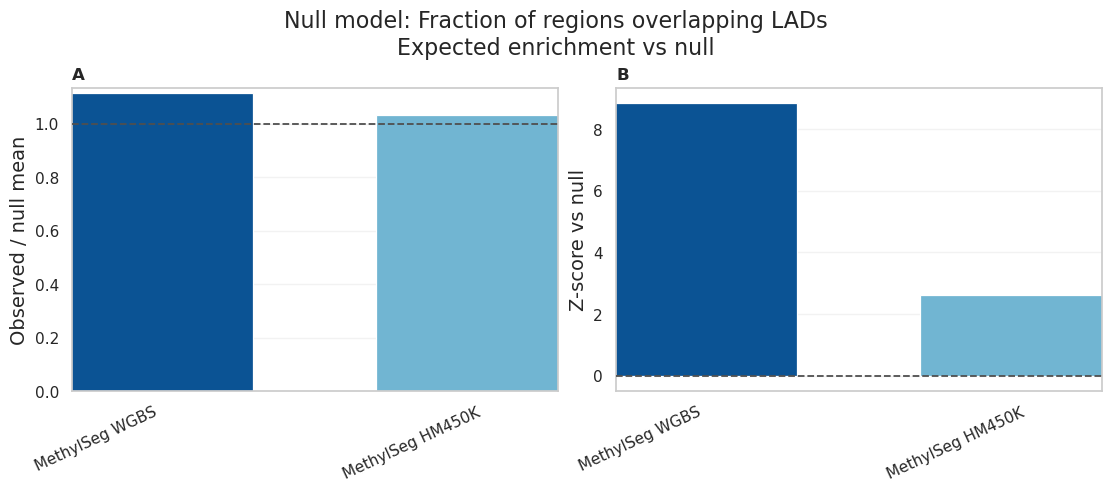

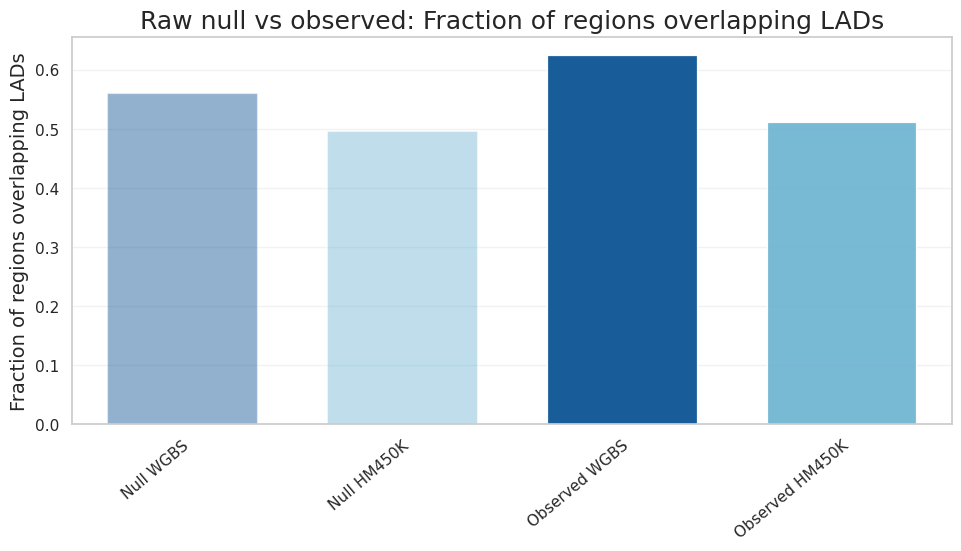

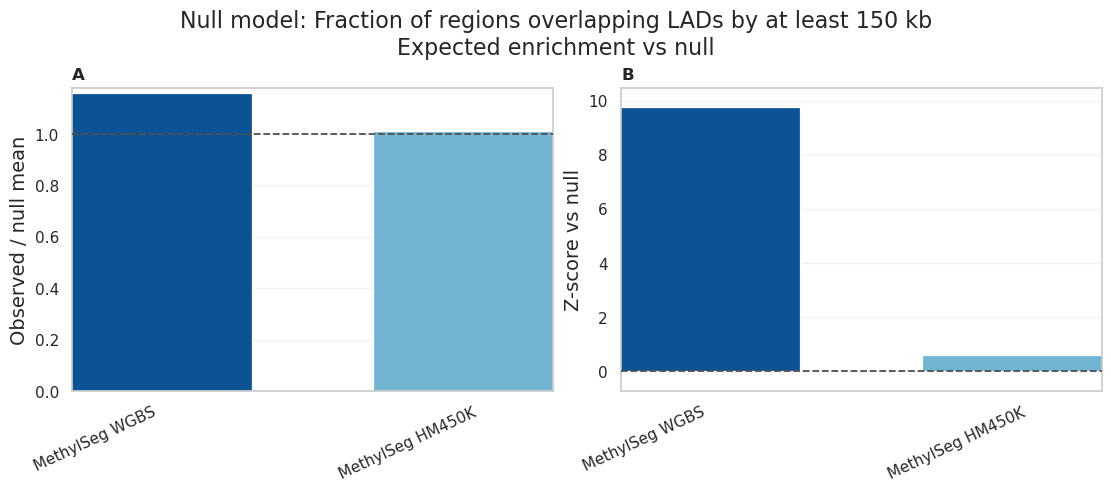

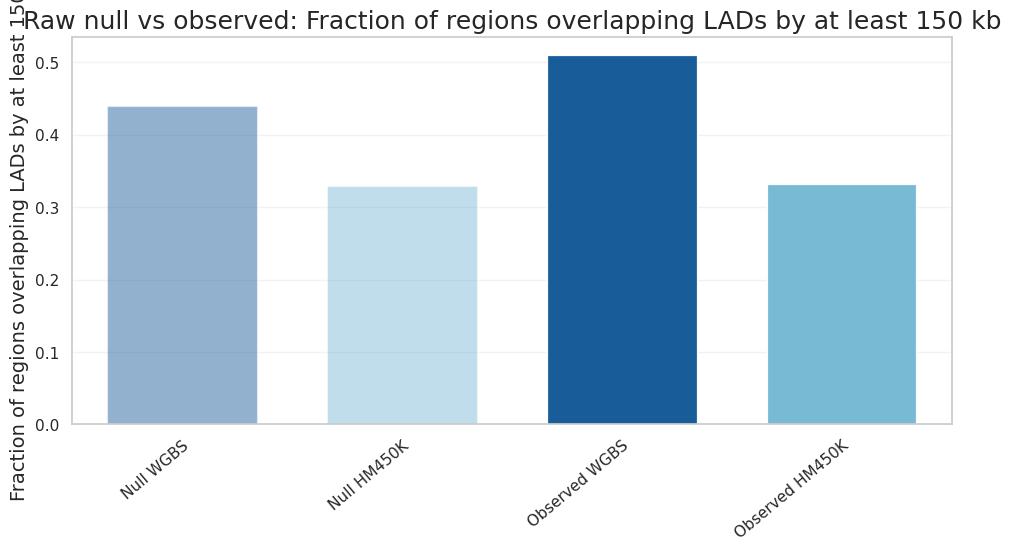

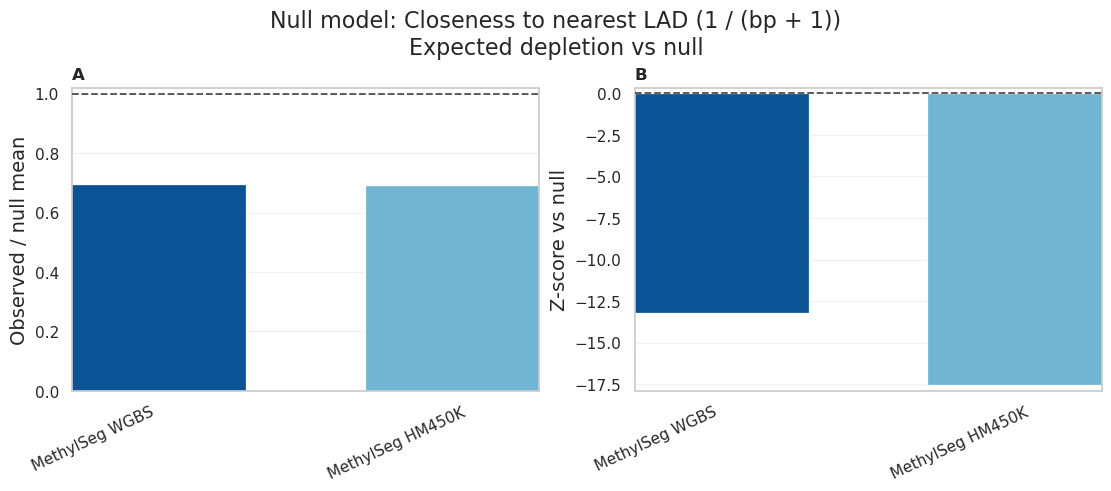

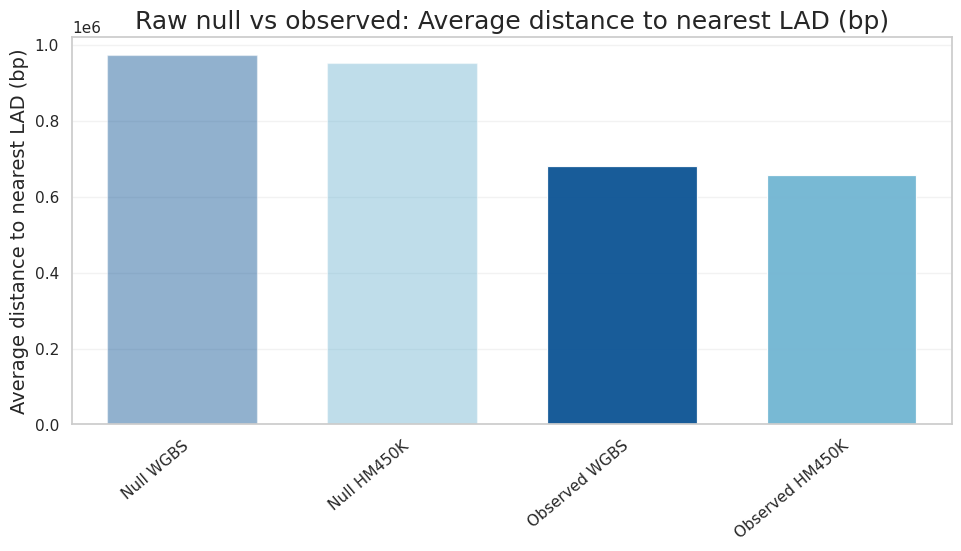

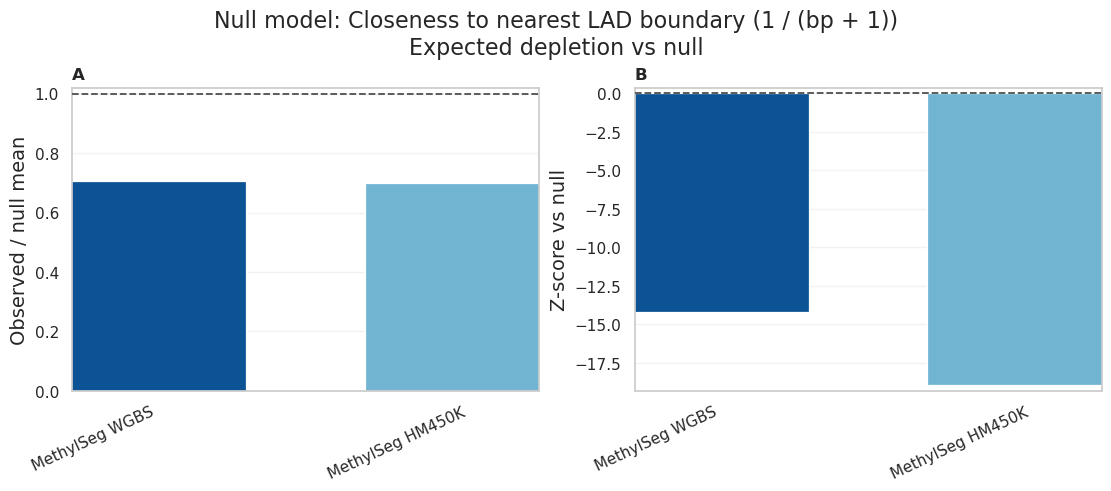

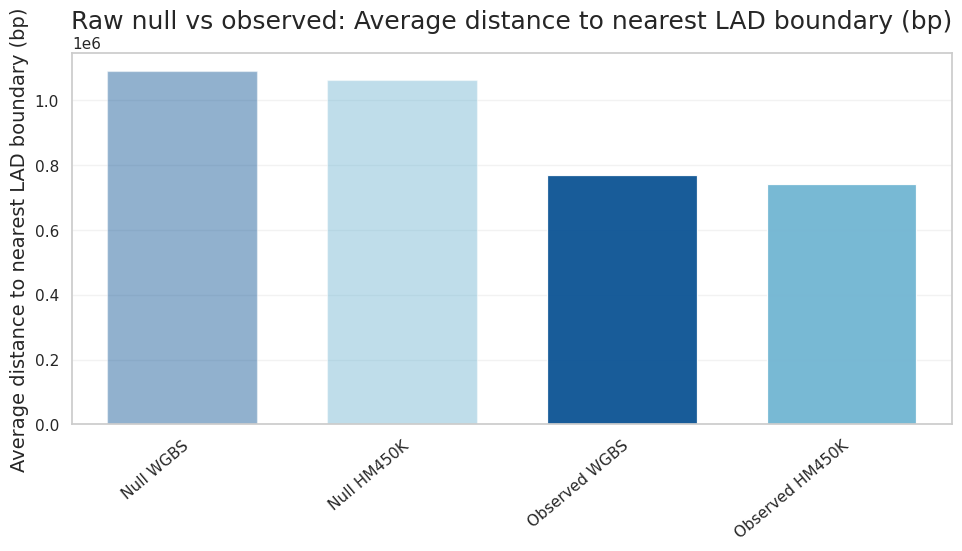

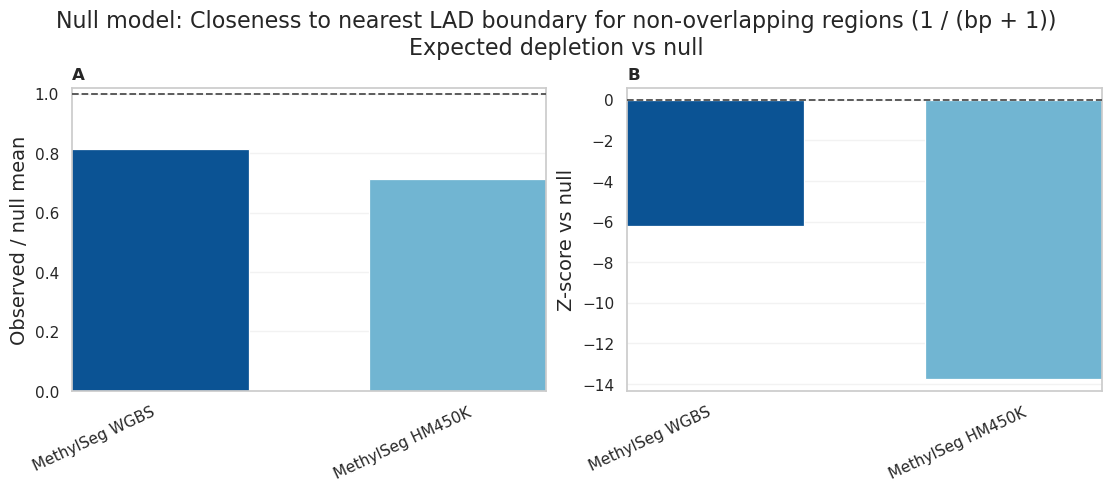

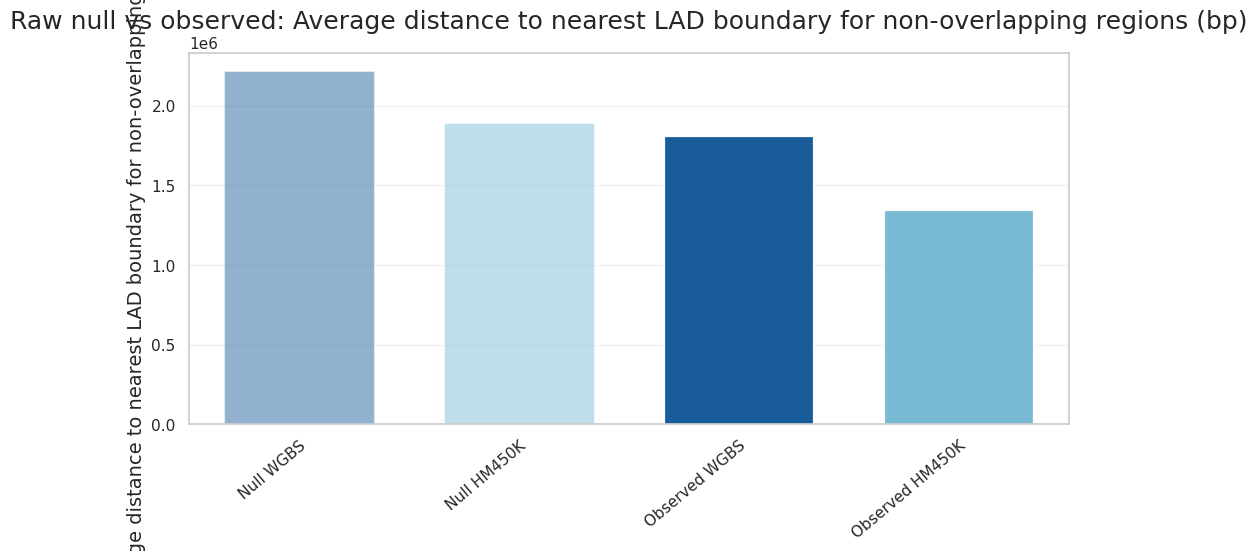

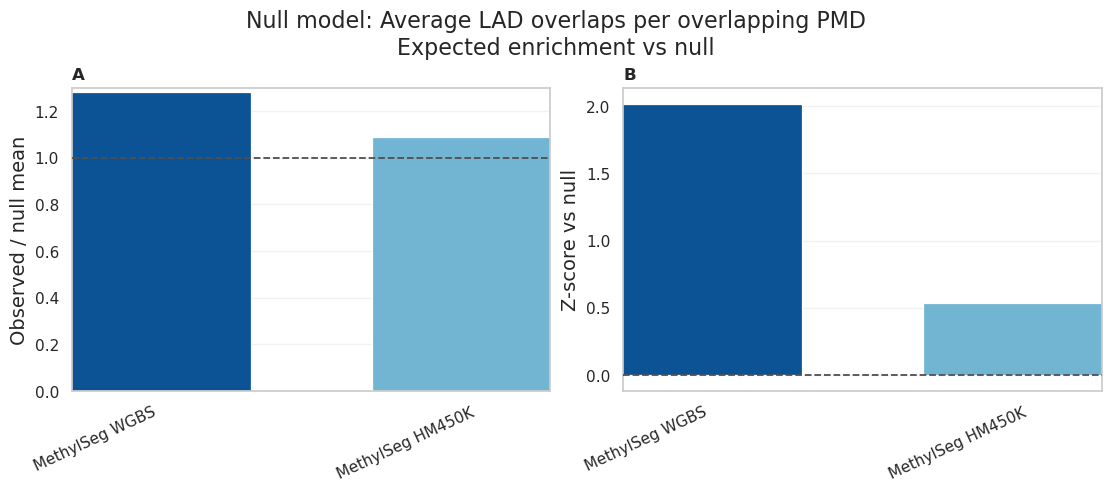

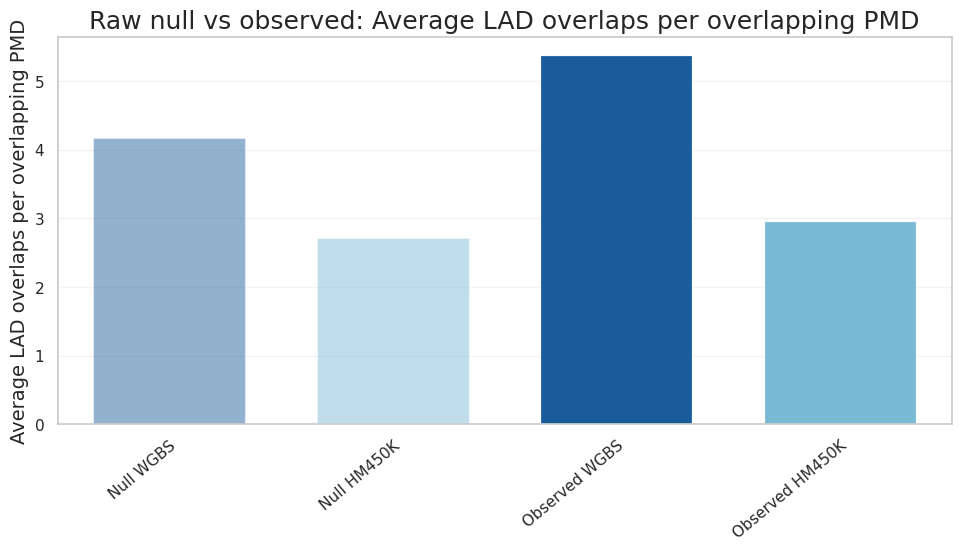

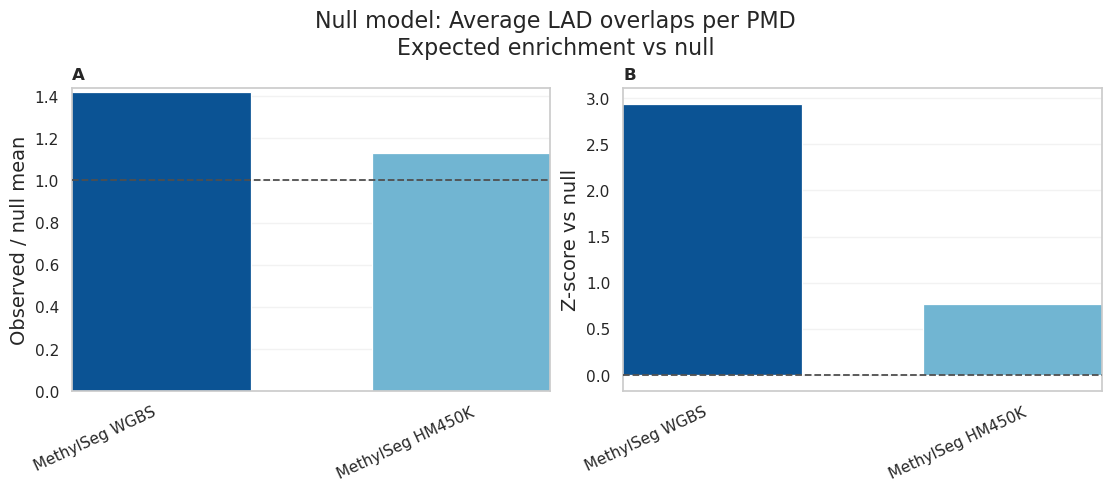

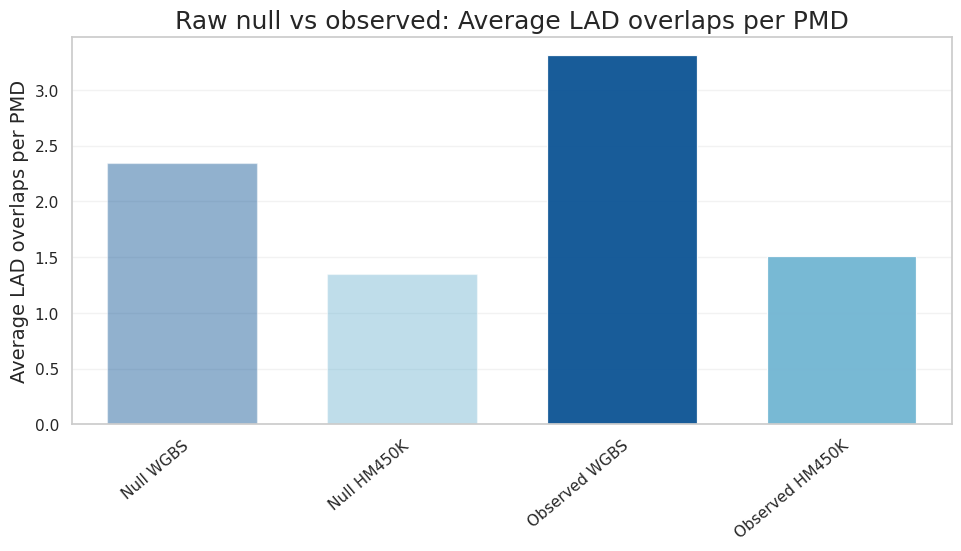

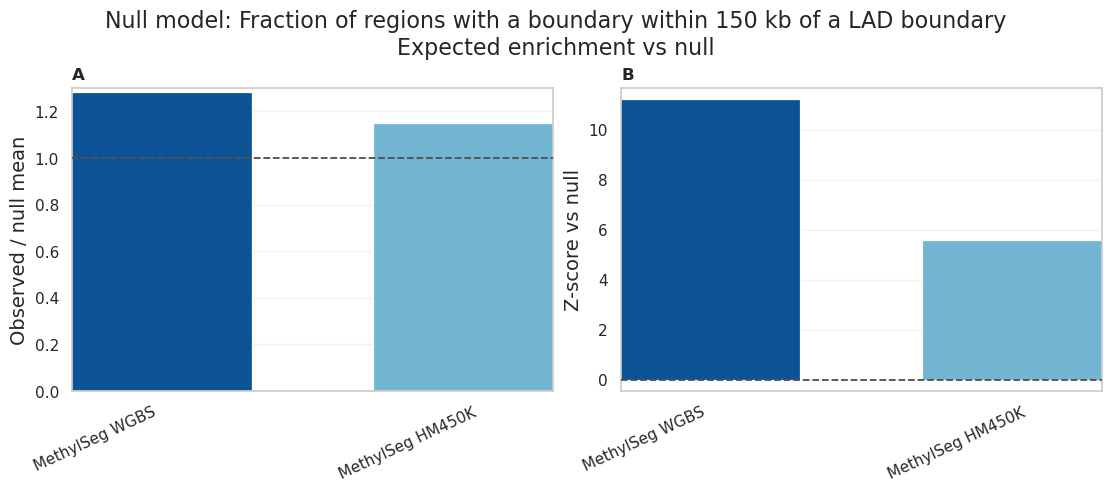

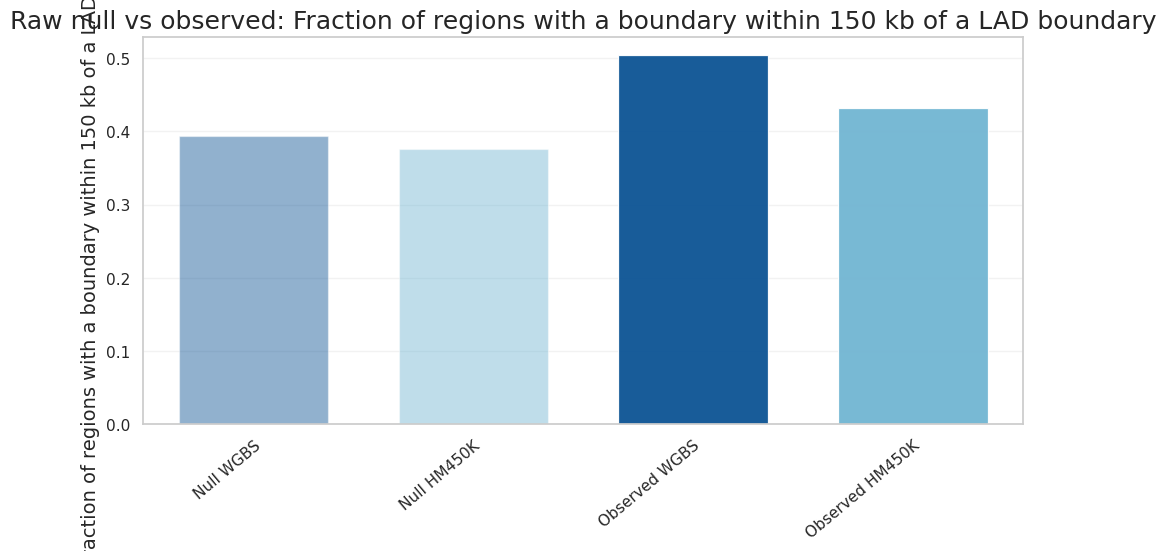

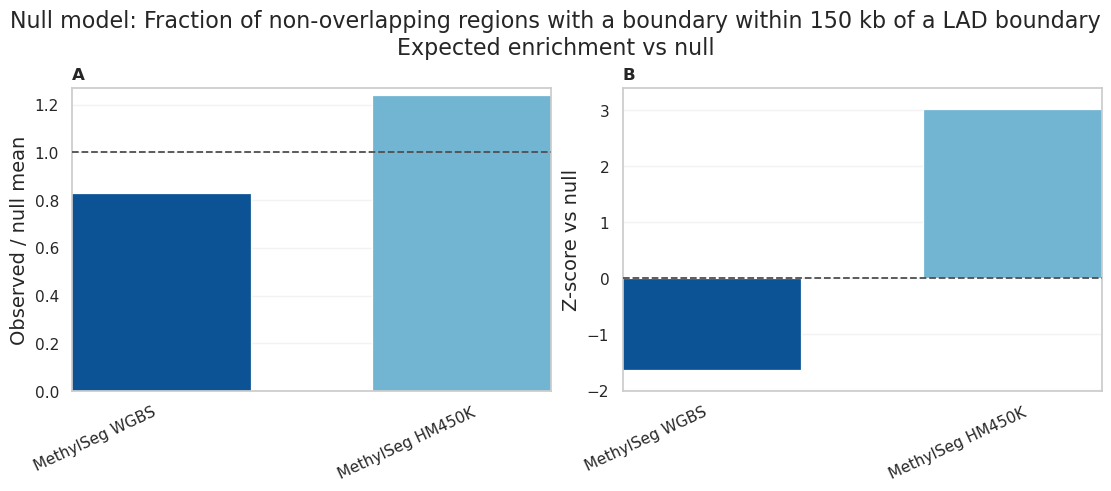

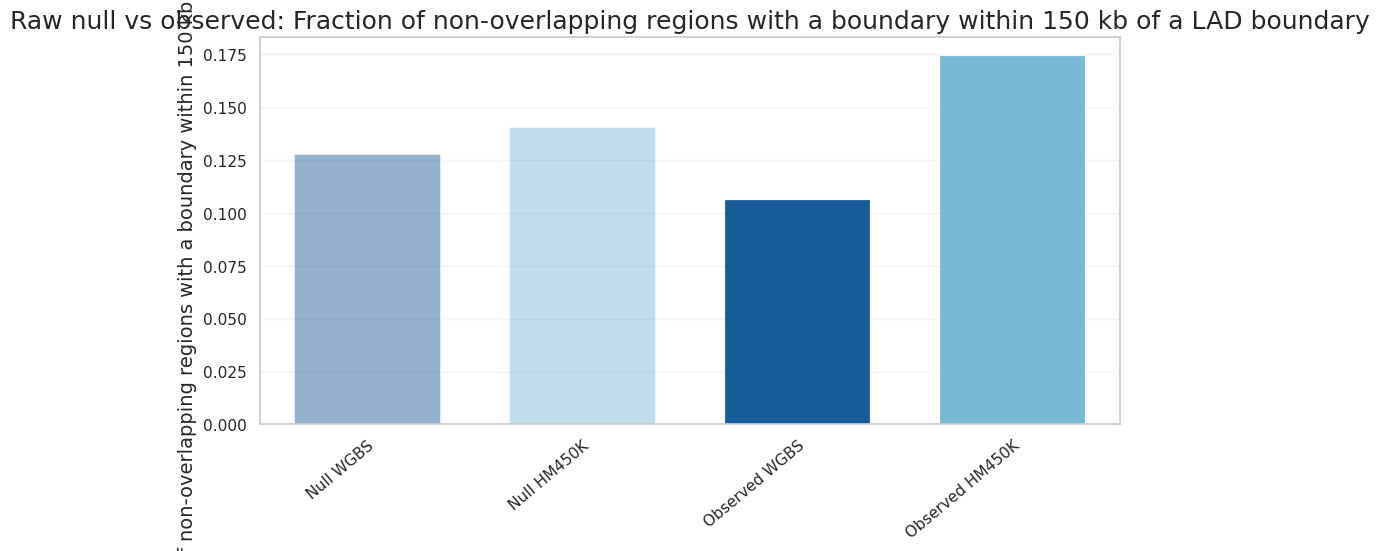

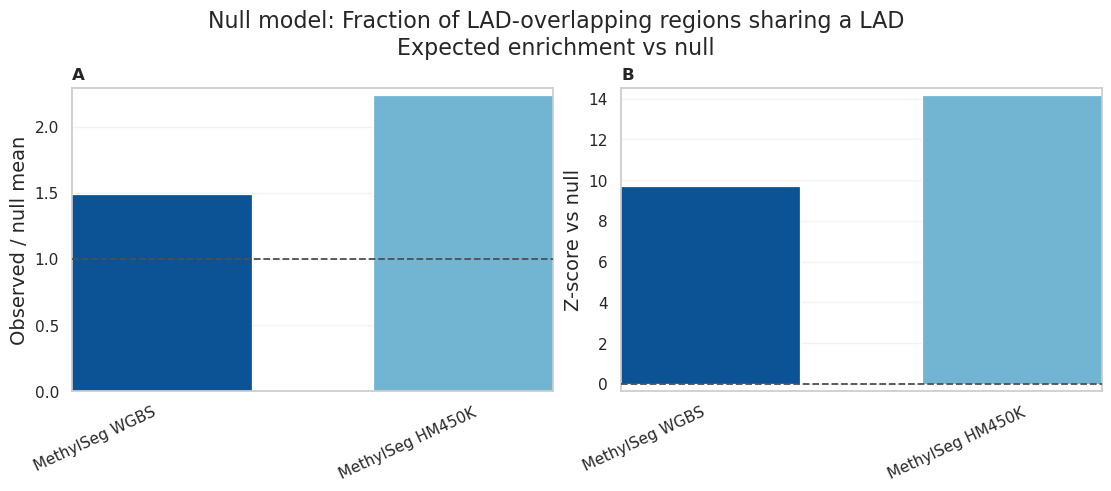

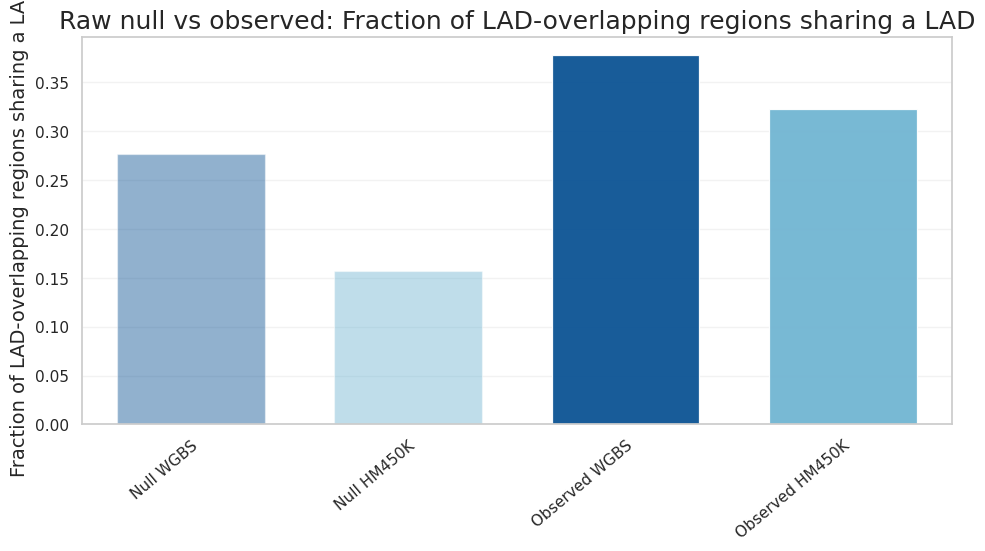

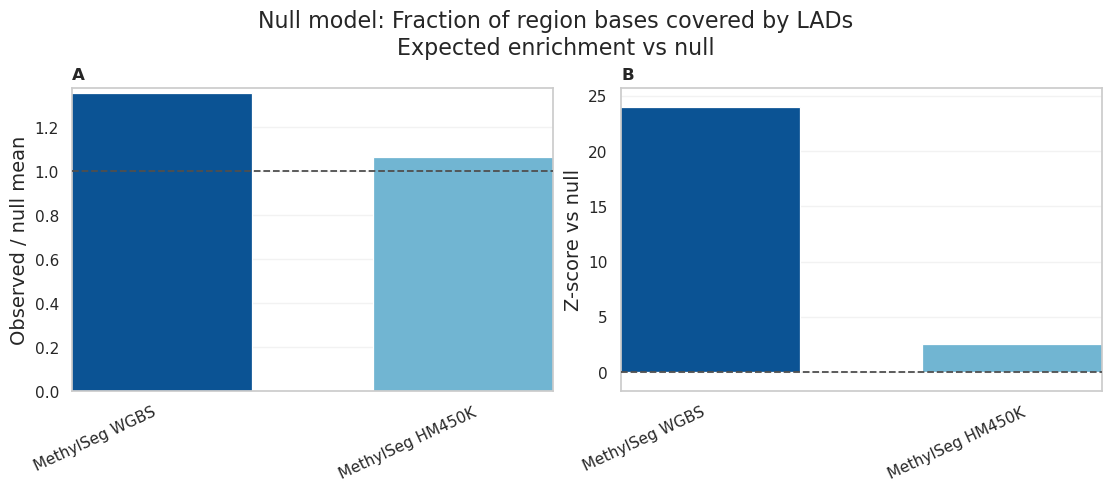

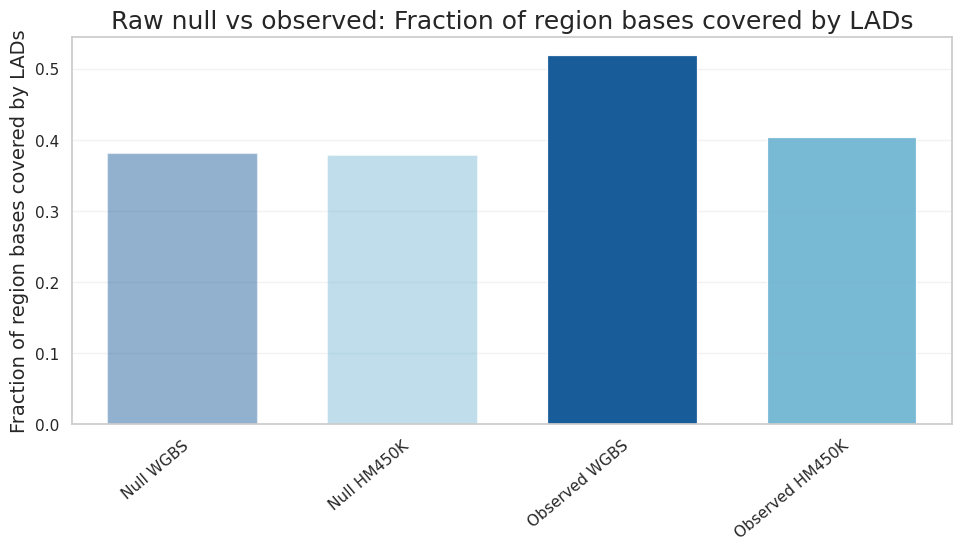

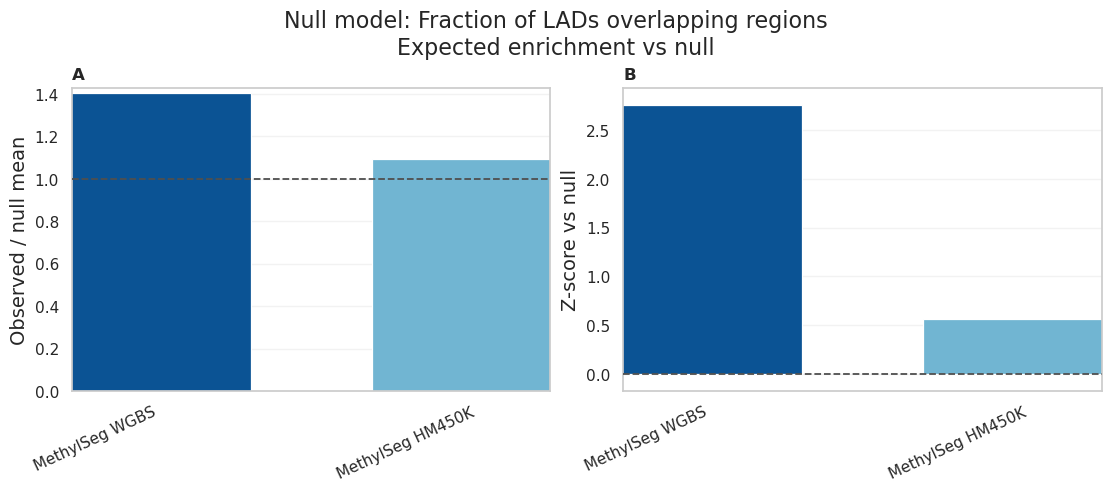

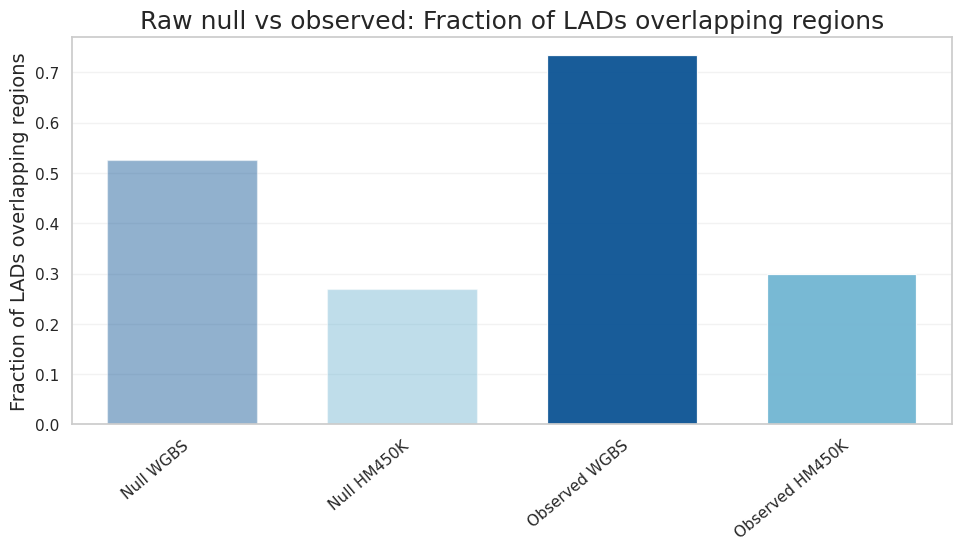

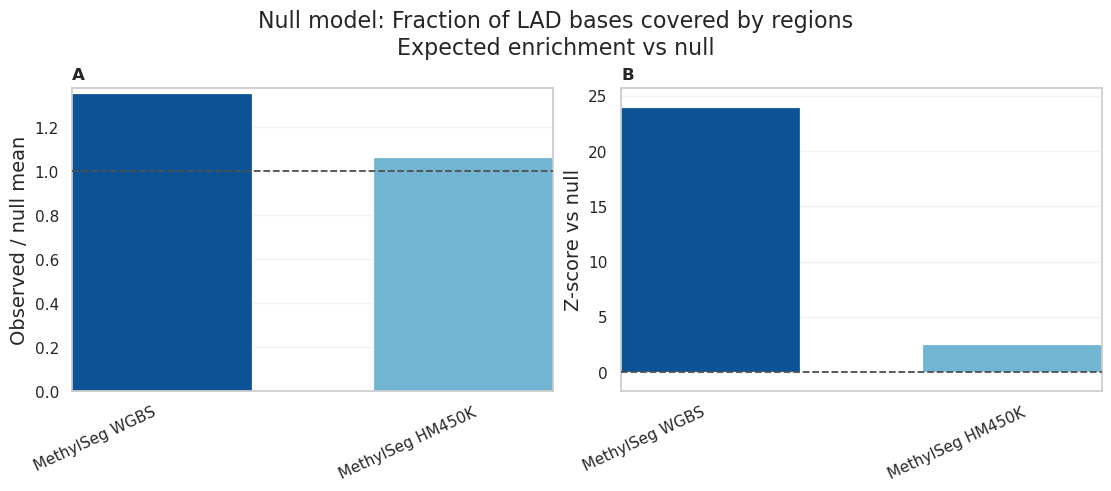

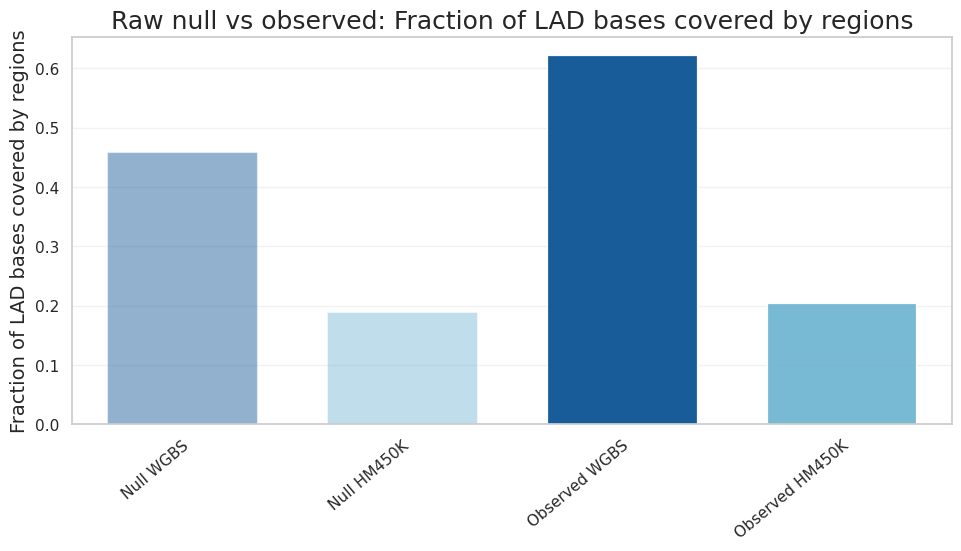

Saved focused LAD null-model figures to /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/05_lad/null_model/methylseg_pair


In [38]:
null_output_dir = OUTPUT_DIR / "null_model" / "methylseg_pair"
null_focus_df = summarize_lad_null_focus_df(null_summary_df)
if null_focus_df.empty:
    raise RuntimeError("No LAD null-summary rows were available for methylseg or methylseg_hm450k")

display(null_focus_df)

null_metric_order = [
    metric_name
    for metric_name in LAD_METRIC_LABELS
    if metric_name in set(null_focus_df["metric"].astype(str))
]
null_metric_order.extend(
    metric_name
    for metric_name in sorted(set(null_focus_df["metric"].astype(str)))
    if metric_name not in set(null_metric_order)
)

for metric_name in null_metric_order:
    metric_df = null_focus_df.loc[null_focus_df["metric"].astype(str) == str(metric_name)].copy()
    if metric_df.empty:
        continue
    fig, _ = plot_lad_null_focus_metric(
        metric_df,
        metric_name=metric_name,
    )
    save_publication_figure(
        fig,
        null_output_dir,
        f"null_pair.{metric_name}.png",
        save_pdf=SAVE_PDF,
    )
    display(fig)
    plt.close(fig)

    raw_fig, _ = plot_lad_null_focus_raw_comparison(
        metric_df,
        metric_name=metric_name,
    )
    save_publication_figure(
        raw_fig,
        null_output_dir,
        f"null_pair.raw_value.{metric_name}.png",
        save_pdf=SAVE_PDF,
    )
    display(raw_fig)
    plt.close(raw_fig)

print(f"Saved focused LAD null-model figures to {null_output_dir}")


In [39]:
display(unique_lad_summary_df)
display(unique_lad_exports_df)
display(profile_outputs_df)


,comparison_tool,reference_methylseg_tool,sample,genome,n_unique_lads,n_unique_regions
0,dnmtools,methylseg,ESO26.wgbs,hg38,1157,63
1,dnmtools,methylseg,TE5.wgbs,hg38,1004,55
2,dnmtools,methylseg,WGBS_colon-primary-tumor_1_meth,hg38,30,5
3,dnmtools_array,methylseg_hm450k,ESO26.wgbs,hg38,229,33
4,dnmtools_array,methylseg_hm450k,TE5.wgbs,hg38,680,55
5,dnmtools_array,methylseg_hm450k,WGBS_colon-primary-tumor_1_meth,hg38,1,1


,comparison_tool,reference_methylseg_tool,sample,genome,n_unique_lads,export_path
0,dnmtools,methylseg,ESO26.wgbs,hg38,1157,/scratch/general/vast/u0914269/methylseg_resul...
1,dnmtools,methylseg,TE5.wgbs,hg38,1004,/scratch/general/vast/u0914269/methylseg_resul...
2,dnmtools,methylseg,WGBS_colon-primary-tumor_1_meth,hg38,30,/scratch/general/vast/u0914269/methylseg_resul...
3,dnmtools_array,methylseg_hm450k,ESO26.wgbs,hg38,229,/scratch/general/vast/u0914269/methylseg_resul...
4,dnmtools_array,methylseg_hm450k,TE5.wgbs,hg38,680,/scratch/general/vast/u0914269/methylseg_resul...
5,dnmtools_array,methylseg_hm450k,WGBS_colon-primary-tumor_1_meth,hg38,1,/scratch/general/vast/u0914269/methylseg_resul...


,sample,sample_id,genome,occupancy_matrix_path,occupancy_sorted_regions_path,occupancy_profile_path,occupancy_heatmap_path,signal_matrix_path,signal_sorted_regions_path,signal_profile_path,signal_heatmap_path,include_heatmaps,visualized_tools


In [40]:
# Region-level violin plots are generated in the next cell.


,sample,sample_id,genome,tool,tool_label,avg_distance_to_nearest_lad,avg_distance_to_nearest_lad_boundary,avg_distance_to_nearest_lad_boundary_non_overlapping,avg_lad_per_pmd,avg_lads_per_overlapping_pmd,lad_coverage_by_pmds,pct_lads_overlapping,pct_non_overlapping_regions_within_150kb_of_lad_boundary,pct_regions_overlapping_lads,pct_regions_overlapping_lads_gte_150kb,pct_regions_with_boundary_within_150kb_of_lad_boundary,pct_regions_with_unique_lad,pmd_coverage_by_lads,total_n_lad_overlaps
0,ESO26.wgbs,ESO26,hg38,methylseg,MethylSeg WGBS,1.637009e-06,1.395256e-06,5.534421e-07,3.258621,4.922990,0.491731,0.613856,0.099778,0.661919,0.539730,0.515742,0.592299,0.536567,4347.0
1,ESO26.wgbs,ESO26,hg38,methylseg_hm450k,MethylSeg HM450K,1.431657e-06,1.289124e-06,7.144335e-07,1.389864,2.774319,0.158772,0.201750,0.138672,0.500975,0.336257,0.412281,0.770428,0.387172,1426.0
2,ESO26.wgbs,ESO26,hg38,methylseekr,MethylSeekR,1.267424e-06,1.153992e-06,7.528150e-07,0.678988,1.672269,0.586195,0.620679,0.179990,0.406028,0.109753,0.364800,0.082866,0.487263,7164.0
3,ESO26.wgbs,ESO26,hg38,dnmtools,DNMTools,1.412177e-06,1.109800e-06,5.616986e-07,1.169643,1.942133,0.309480,0.383178,0.128892,0.602247,0.133929,0.324021,0.101865,0.636251,4061.0
4,ESO26.wgbs,ESO26,hg38,dnmtools_array,DNMTools Array,2.501605e-06,2.122099e-06,6.163386e-07,5.695652,7.557692,0.040006,0.058300,0.235294,0.753623,0.739130,0.637681,1.000000,0.531896,393.0
5,ESO26.wgbs,ESO26,hg38,dnmtools_pmr,DNMTools PMR,1.722185e-06,1.265777e-06,7.991553e-07,0.539346,1.006308,0.062756,0.194630,0.184517,0.535965,0.000000,0.264601,0.021684,0.558976,12762.0
6,ESO26.wgbs,ESO26,hg38,mmseekr,MMSeekR,1.640734e-06,1.349467e-06,7.292644e-07,1.084624,1.952427,0.486347,0.422044,0.143544,0.555526,0.205553,0.377202,0.183085,0.586809,4063.0
7,ESO26.wgbs,ESO26,hg38,methyl_lasso,MethylLasso,1.211550e-06,1.027126e-06,5.762446e-07,0.814390,1.553070,0.472101,0.481086,0.155111,0.524374,0.146246,0.346064,0.090728,0.563852,6248.0
8,TE5.wgbs,TE5,hg38,methylseg,MethylSeg WGBS,1.663020e-06,1.424756e-06,5.742477e-07,2.908287,4.442194,0.617949,0.729417,0.128000,0.654696,0.501657,0.524862,0.527426,0.517759,5264.0
9,TE5.wgbs,TE5,hg38,methylseg_hm450k,MethylSeg HM450K,1.441876e-06,1.283901e-06,7.123898e-07,1.619895,3.201823,0.190843,0.343124,0.176000,0.505929,0.303030,0.430171,0.653646,0.389273,2459.0


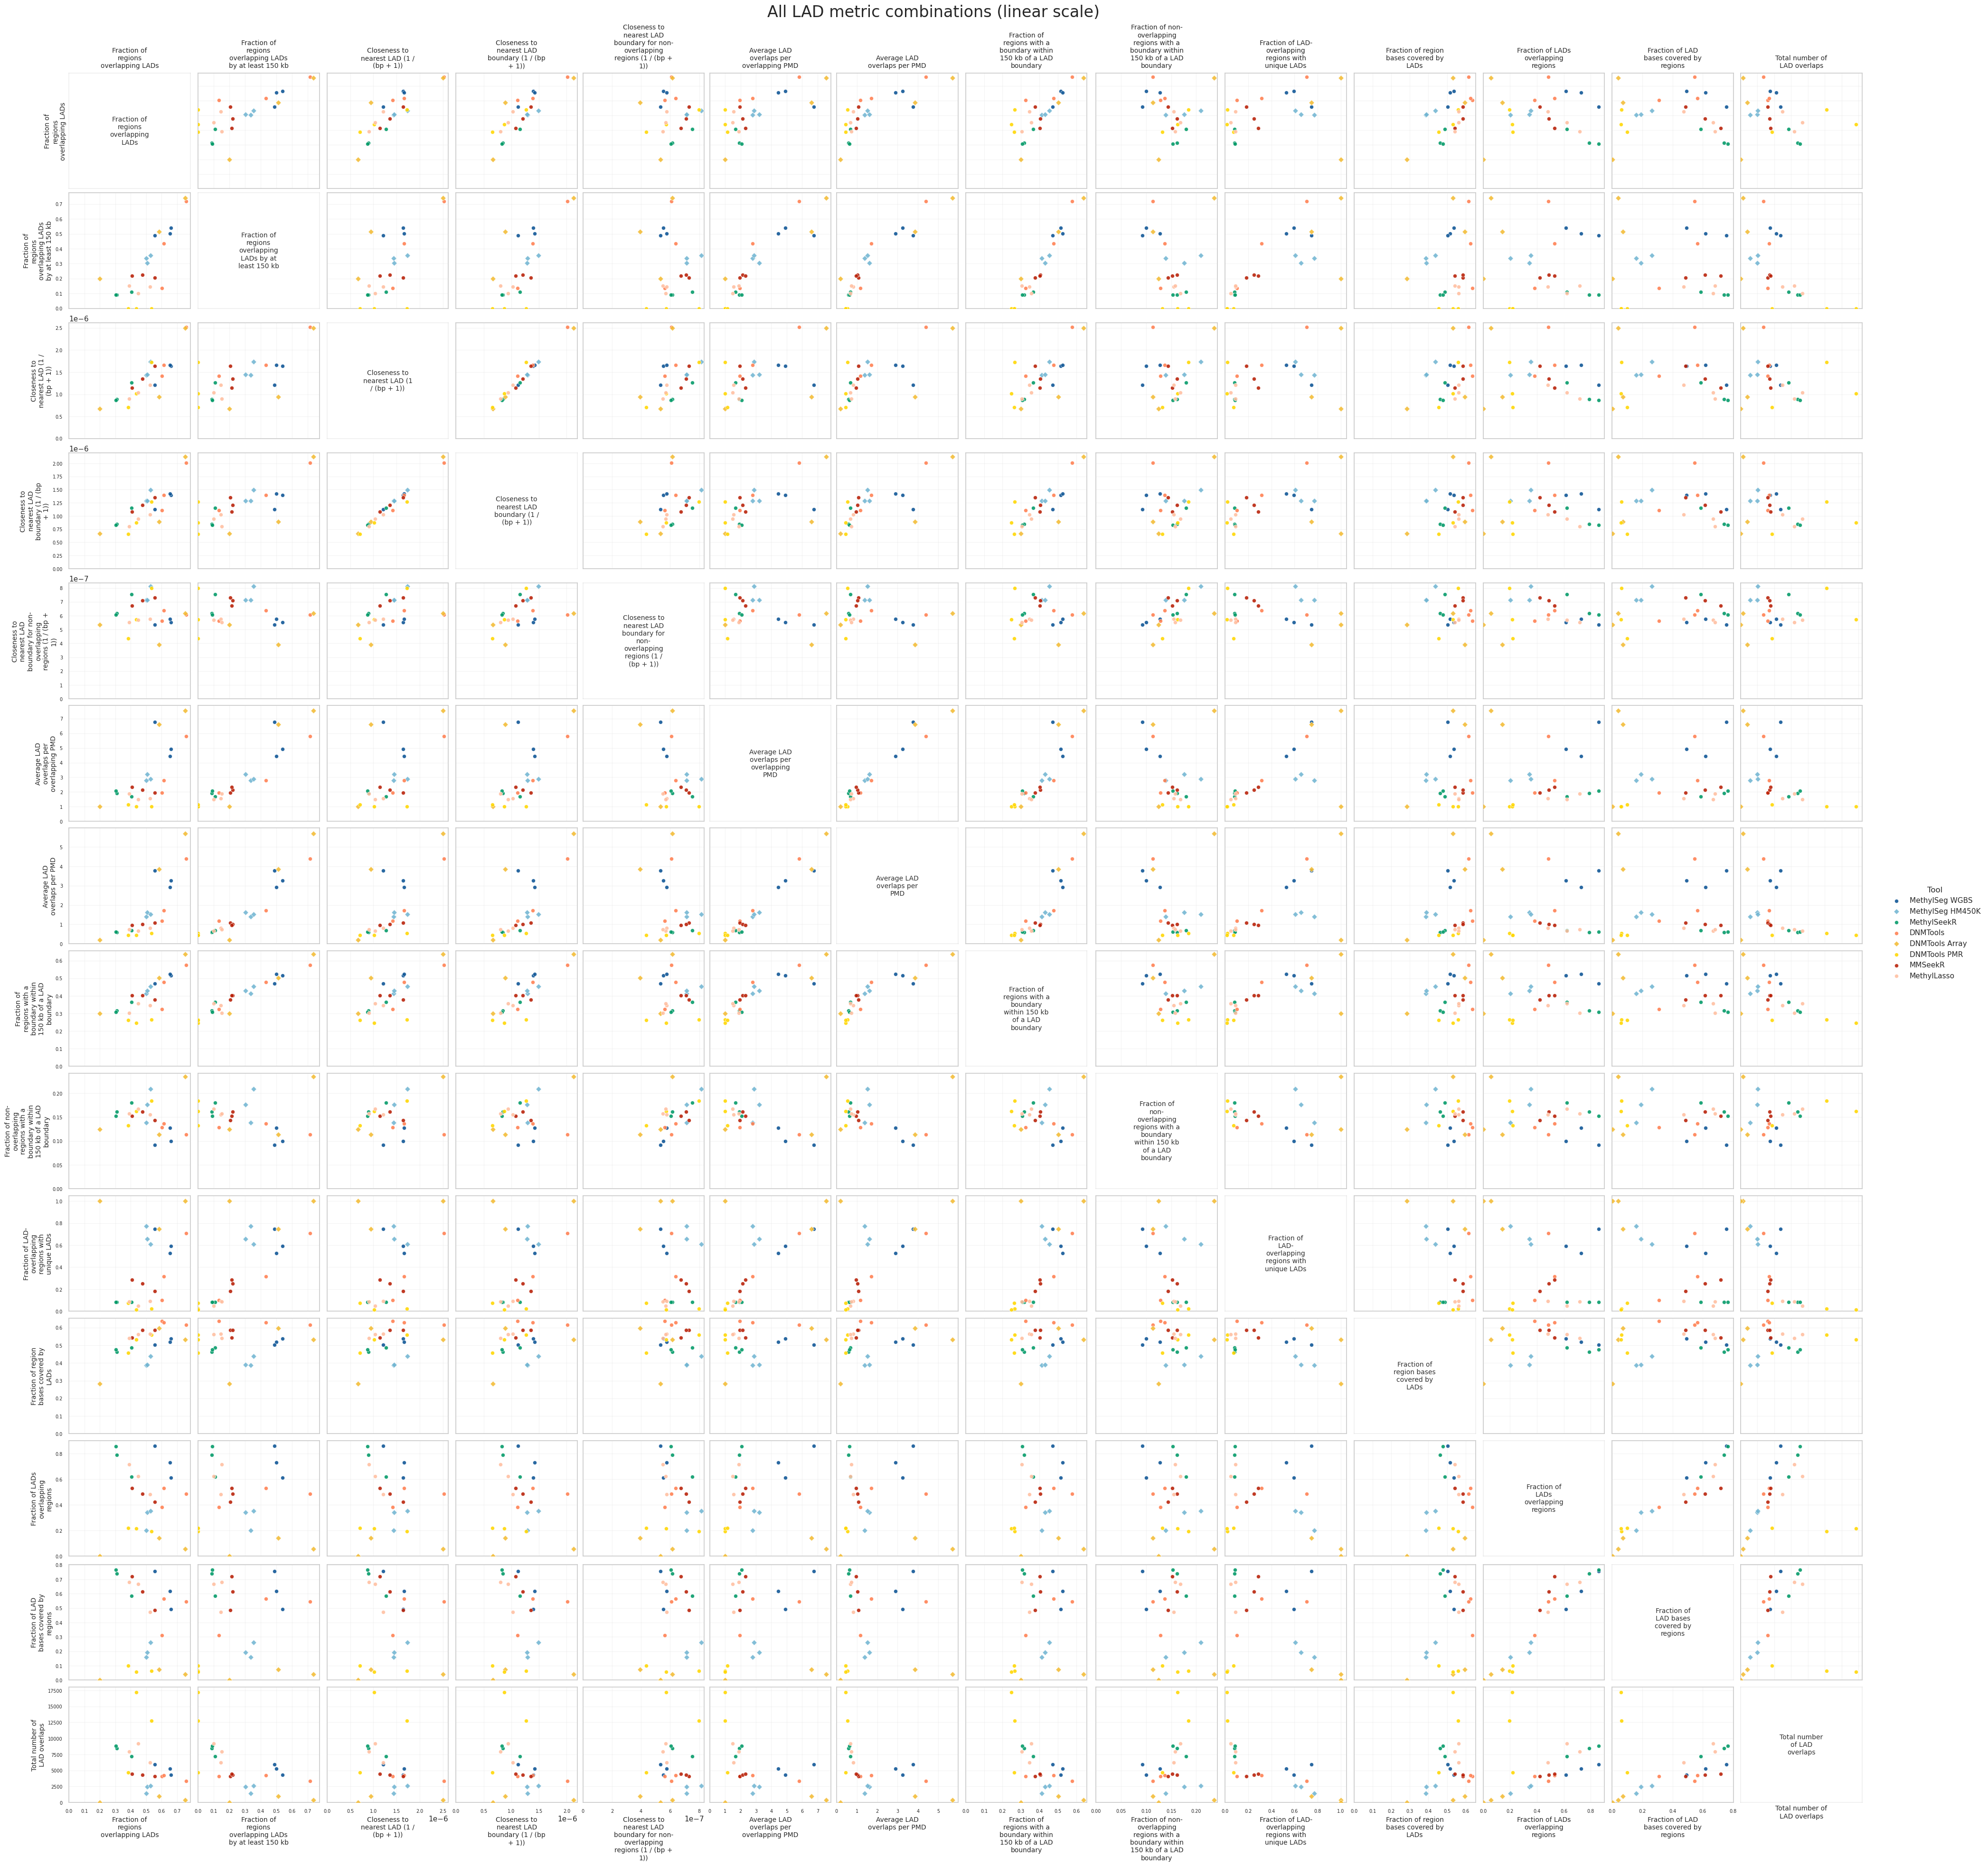

In [41]:
plot_sample_label = (
    "all_samples" if REGION_PLOT_SAMPLE_ID is None else f"sample_id_{REGION_PLOT_SAMPLE_ID}"
)
plot_title_label = (
    "All samples" if REGION_PLOT_SAMPLE_ID is None else f"sample_id={REGION_PLOT_SAMPLE_ID}"
)
violin_output_dir = OUTPUT_DIR / "violin_metrics" / plot_sample_label
violin_metric_specs = [
    ("total_lad_overlap_bp", lad_region_overlap_details_df, "Per-region total LAD overlap (bp)"),
    (
        "lad_overlap_fraction",
        lad_region_overlap_details_df,
        "Per-region fraction overlapping LADs",
    ),
]

# for metric_name, source_df, ylabel in violin_metric_specs:
#     metric_df = filter_lad_region_plot_df(source_df, REGION_PLOT_SAMPLE_ID)
#     if metric_df.empty:
#         raise RuntimeError(
#             f"No violin rows available for {metric_name!r} with REGION_PLOT_SAMPLE_ID={REGION_PLOT_SAMPLE_ID!r}"
#         )
#     fig, _ = plot_lad_metric_violin(
#         metric_df,
#         value_col=metric_name,
#         title=f"LAD region spread ({plot_title_label}): {metric_label(metric_name)}",
#         ylabel=ylabel,
#     )
#     save_publication_figure(
#         fig,
#         violin_output_dir,
#         f"violin.{metric_name}.png",
#         save_pdf=SAVE_PDF,
#     )
#     plt.show()
#     plt.close(fig)

coverage_scatter_output_dir = OUTPUT_DIR / "coverage_scatter" / plot_sample_label
coverage_scatter_metrics_df = filter_lad_region_plot_df(metrics_df, REGION_PLOT_SAMPLE_ID)
coverage_scatter_overlap_details_df = filter_lad_region_plot_df(
    lad_region_overlap_details_df,
    REGION_PLOT_SAMPLE_ID,
)
all_lad_metric_scatter_df, all_lad_metric_order = summarize_lad_metric_scatter_matrix_df(
    coverage_scatter_metrics_df,
    coverage_scatter_overlap_details_df,
)

display(all_lad_metric_scatter_df)

linear_grid_title = "All LAD metric combinations (linear scale)"
if REGION_PLOT_SAMPLE_ID is not None:
    linear_grid_title = f"{linear_grid_title} ({plot_title_label})"
linear_scatter_grid_fig, _ = plot_lad_metric_combination_grid(
    all_lad_metric_scatter_df,
    all_lad_metric_order,
    title=linear_grid_title,
    axis_scale="linear",
)
save_publication_figure(
    linear_scatter_grid_fig,
    coverage_scatter_output_dir,
    "lad_metric_scatter_grid_linear.png",
    save_pdf=SAVE_PDF,
)
display(linear_scatter_grid_fig)
plt.close(linear_scatter_grid_fig)

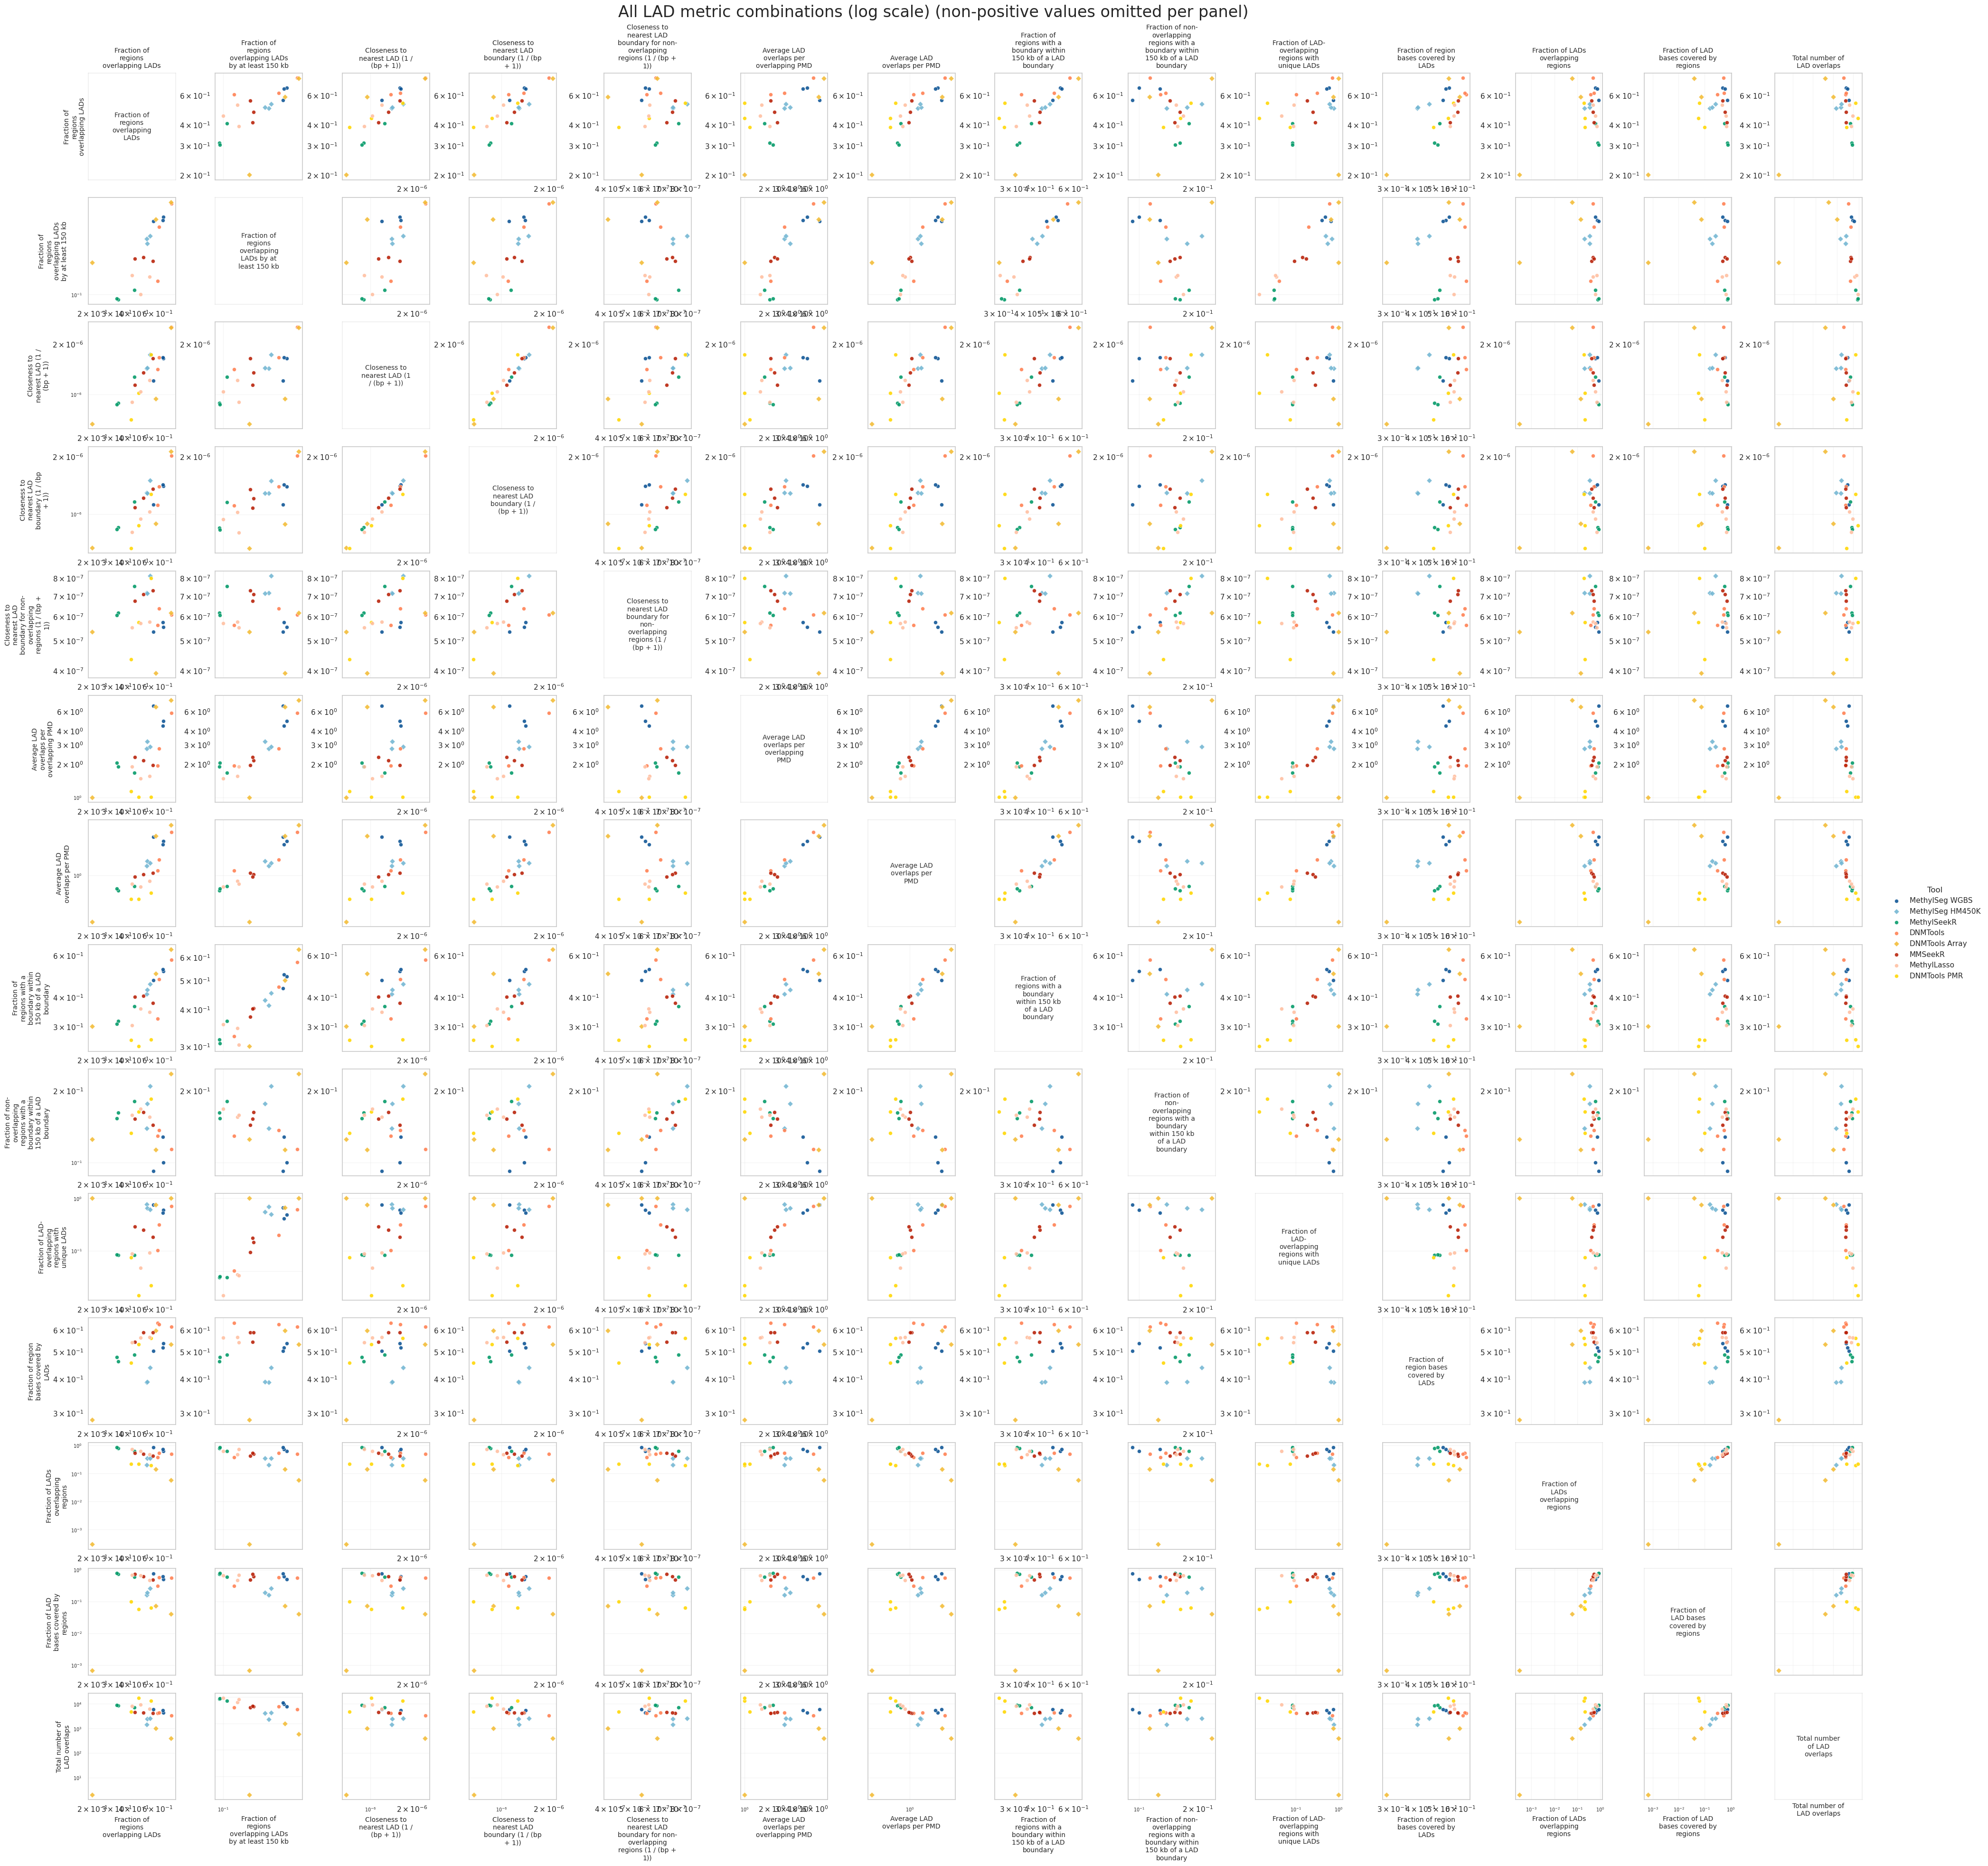

Saved LAD coverage scatter figures to /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/05_lad/coverage_scatter/all_samples


In [42]:
log_grid_title = "All LAD metric combinations (log scale)"
if REGION_PLOT_SAMPLE_ID is not None:
    log_grid_title = f"{log_grid_title} ({plot_title_label})"
log_scatter_grid_fig, _ = plot_lad_metric_combination_grid(
    all_lad_metric_scatter_df,
    all_lad_metric_order,
    title=log_grid_title,
    axis_scale="log",
)
save_publication_figure(
    log_scatter_grid_fig,
    coverage_scatter_output_dir,
    "lad_metric_scatter_grid_log.png",
    save_pdf=SAVE_PDF,
)
display(log_scatter_grid_fig)
plt.close(log_scatter_grid_fig)
print(f"Saved LAD coverage scatter figures to {coverage_scatter_output_dir}")

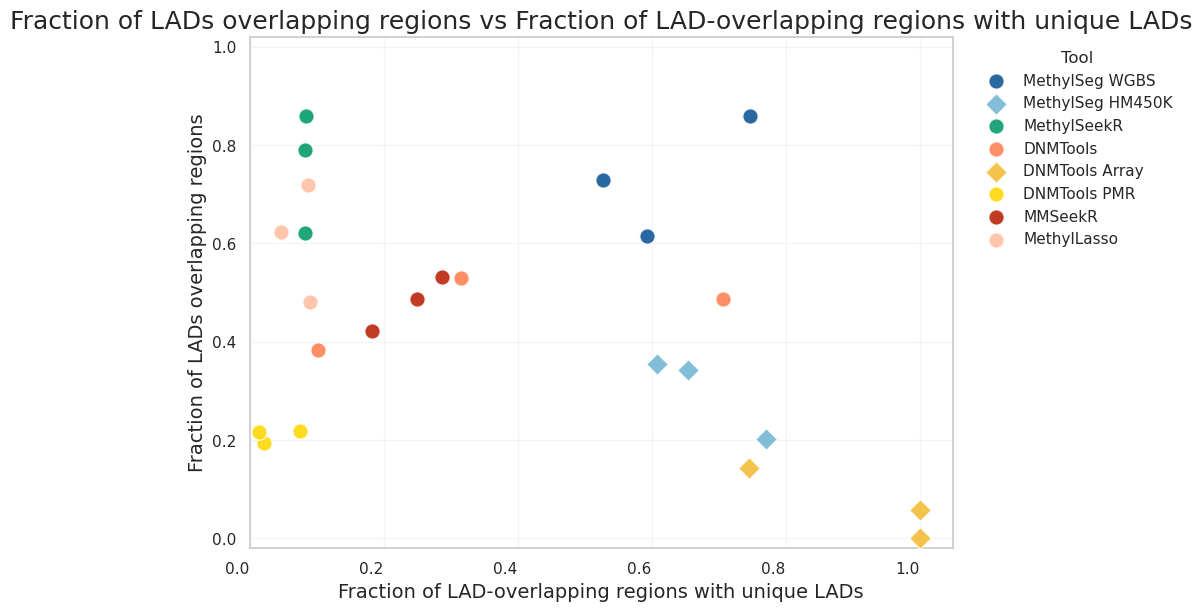

In [43]:
# Valid LAD metric names for x_metric and y_metric:
# - avg_distance_to_nearest_lad
# - avg_distance_to_nearest_lad_boundary
# - avg_distance_to_nearest_lad_boundary_non_overlapping
# - lad_coverage_by_pmds
# - pct_lads_overlapping
# - pct_non_overlapping_regions_within_150kb_of_lad_boundary
# - pct_regions_overlapping_lads
# - pct_regions_overlapping_lads_gte_150kb
# - pct_regions_with_unique_lad
# - pct_regions_with_boundary_within_150kb_of_lad_boundary
# - pmd_coverage_by_lads
# - avg_lads_per_overlapping_pmd
# - avg_lad_per_pmd
# - total_n_lad_overlaps

def plot_single_lad_metric_pair(
    x_metric: str,
    y_metric: str,
    scale: str = "linear",
):
    if scale not in {"linear", "log"}:
        raise ValueError(f"scale must be 'linear' or 'log', got {scale!r}")
    if x_metric not in all_lad_metric_order:
        raise ValueError(f"Unknown x_metric={x_metric!r}. Choices: {all_lad_metric_order}")
    if y_metric not in all_lad_metric_order:
        raise ValueError(f"Unknown y_metric={y_metric!r}. Choices: {all_lad_metric_order}")

    pair_title = f"{metric_label(y_metric)} vs {metric_label(x_metric)}"
    if REGION_PLOT_SAMPLE_ID is not None:
        pair_title = f"{pair_title} ({plot_title_label})"

    fig, ax = plot_lad_summary_scatter(
        all_lad_metric_scatter_df,
        x_col=x_metric,
        y_col=y_metric,
        title=pair_title,
        xlabel=metric_label(x_metric),
        ylabel=metric_label(y_metric),
        x_scale=scale,
    )
    if scale == "log":
        ax.set_yscale("log")
    return fig, ax


# Example:
fig, ax = plot_single_lad_metric_pair(
    x_metric="pct_regions_with_unique_lad",
    y_metric="pct_lads_overlapping",
    scale="linear",
)
display(fig)
plt.close(fig)


In [44]:
# Valid LAD metric names for x_metric, y_metric, and z_metric:
# - avg_distance_to_nearest_lad
# - avg_distance_to_nearest_lad_boundary
# - avg_distance_to_nearest_lad_boundary_non_overlapping
# - lad_coverage_by_pmds
# - pct_lads_overlapping
# - pct_non_overlapping_regions_within_150kb_of_lad_boundary
# - pct_regions_overlapping_lads
# - pct_regions_overlapping_lads_gte_150kb
# - pct_regions_with_unique_lad
# - pct_regions_with_boundary_within_150kb_of_lad_boundary
# - pmd_coverage_by_lads
# - avg_lads_per_overlapping_pmd
# - avg_lad_per_pmd
# - total_n_lad_overlaps

import plotly.graph_objects as go

def plot_three_lad_metrics(
    x_metric: str,
    y_metric: str,
    z_metric: str,
    scale: str = "linear",
):
    if scale not in {"linear", "log"}:
        raise ValueError(f"scale must be 'linear' or 'log', got {scale!r}")

    for metric_name, axis_name in zip(
        [x_metric, y_metric, z_metric],
        ["x_metric", "y_metric", "z_metric"],
    ):
        if metric_name not in all_lad_metric_order:
            raise ValueError(f"Unknown {axis_name}={metric_name!r}. Choices: {all_lad_metric_order}")

    plot_df = all_lad_metric_scatter_df.loc[
        :,
        ["tool", "tool_label", x_metric, y_metric, z_metric],
    ].copy()
    for metric_name in [x_metric, y_metric, z_metric]:
        plot_df[metric_name] = pd.to_numeric(plot_df[metric_name], errors="coerce")
    plot_df = plot_df.dropna(subset=[x_metric, y_metric, z_metric]).reset_index(drop=True)
    if plot_df.empty:
        raise RuntimeError("No finite rows found for the requested LAD metric trio")

    n_excluded = 0
    if scale == "log":
        positive_mask = (
            plot_df[x_metric].gt(0)
            & plot_df[y_metric].gt(0)
            & plot_df[z_metric].gt(0)
        )
        n_excluded = int((~positive_mask).sum())
        plot_df = plot_df.loc[positive_mask].reset_index(drop=True)
        if plot_df.empty:
            raise RuntimeError("No positive rows found for the requested LAD metric trio on log scale")

    ordered_labels = lad_tool_label_order(plot_df)
    scatter_palette = lad_scatter_palette(plot_df)
    marker_symbol_map = {
        "o": "circle",
        "D": "diamond",
        "s": "square",
    }
    fig = go.Figure()

    for tool_label in ordered_labels:
        tool_df = plot_df.loc[plot_df["tool_label"] == tool_label]
        if tool_df.empty:
            continue
        tool_name = str(tool_df["tool"].iloc[0])
        marker_symbol = marker_symbol_map.get(lad_tool_marker(tool_name), "circle")
        fig.add_trace(go.Scatter3d(
            x=tool_df[x_metric],
            y=tool_df[y_metric],
            z=tool_df[z_metric],
            mode="markers",
            name=str(tool_label),
            marker=dict(
                size=8,
                symbol=marker_symbol,
                color=scatter_palette[tool_label],
                line=dict(color=NEUTRAL_COLORS["white"], width=1),
                opacity=0.9,
            ),
            customdata=tool_df[["tool_label"]].astype(str).to_numpy(),
            hovertemplate=(
                "Tool: %{customdata[0]}<br>"
                + f"{metric_label(x_metric)}: " + "%{x:.4g}<br>"
                + f"{metric_label(y_metric)}: " + "%{y:.4g}<br>"
                + f"{metric_label(z_metric)}: " + "%{z:.4g}<extra></extra>"
            ),
        ))

    plot_title = (
        f"{metric_label(z_metric)} vs {metric_label(x_metric)} and {metric_label(y_metric)}"
    )
    if REGION_PLOT_SAMPLE_ID is not None:
        plot_title = f"{plot_title} ({plot_title_label})"

    scene_axes = {
        "xaxis_title": metric_label(x_metric),
        "yaxis_title": metric_label(y_metric),
        "zaxis_title": metric_label(z_metric),
        "camera": {"eye": {"x": 1.5, "y": 1.5, "z": 1.0}},
    }

    if scale == "log":
        scene_axes["xaxis_type"] = "log"
        scene_axes["yaxis_type"] = "log"
        scene_axes["zaxis_type"] = "log"
        if n_excluded:
            plot_title = f"{plot_title}<br><sup>Excluded {n_excluded} non-positive sample(s) for log scale</sup>"
    else:
        if float(plot_df[x_metric].min()) >= 0:
            scene_axes["xaxis_rangemode"] = "tozero"
        if float(plot_df[y_metric].min()) >= 0:
            scene_axes["yaxis_rangemode"] = "tozero"
        if float(plot_df[z_metric].min()) >= 0:
            scene_axes["zaxis_rangemode"] = "tozero"

    fig.update_layout(
        title=plot_title,
        scene=scene_axes,
        template="plotly_white",
        legend=dict(title="Tool"),
        width=980,
        height=760,
        margin=dict(l=0, r=0, t=80, b=0),
    )
    return fig


# Example:
fig = plot_three_lad_metrics(
    x_metric="avg_distance_to_nearest_lad",
    y_metric="pct_regions_overlapping_lads_gte_150kb",
    z_metric="pct_lads_overlapping",
    scale="linear",
)
fig


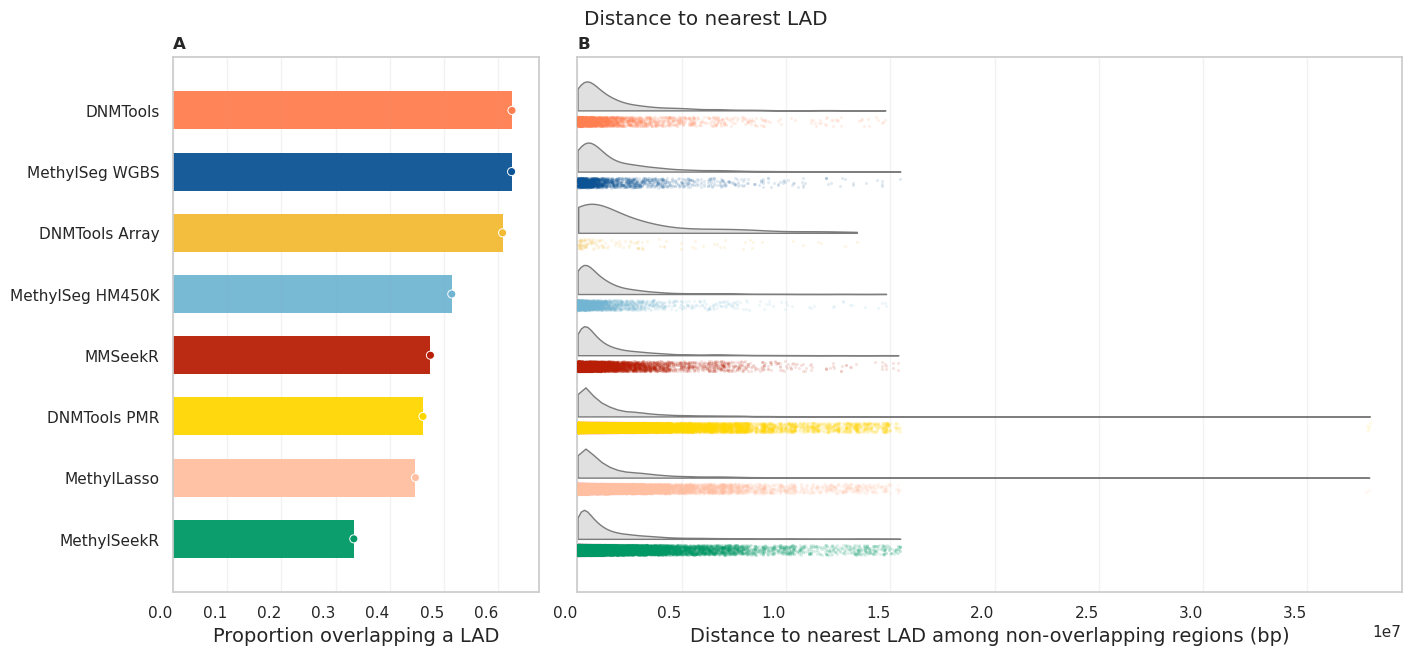

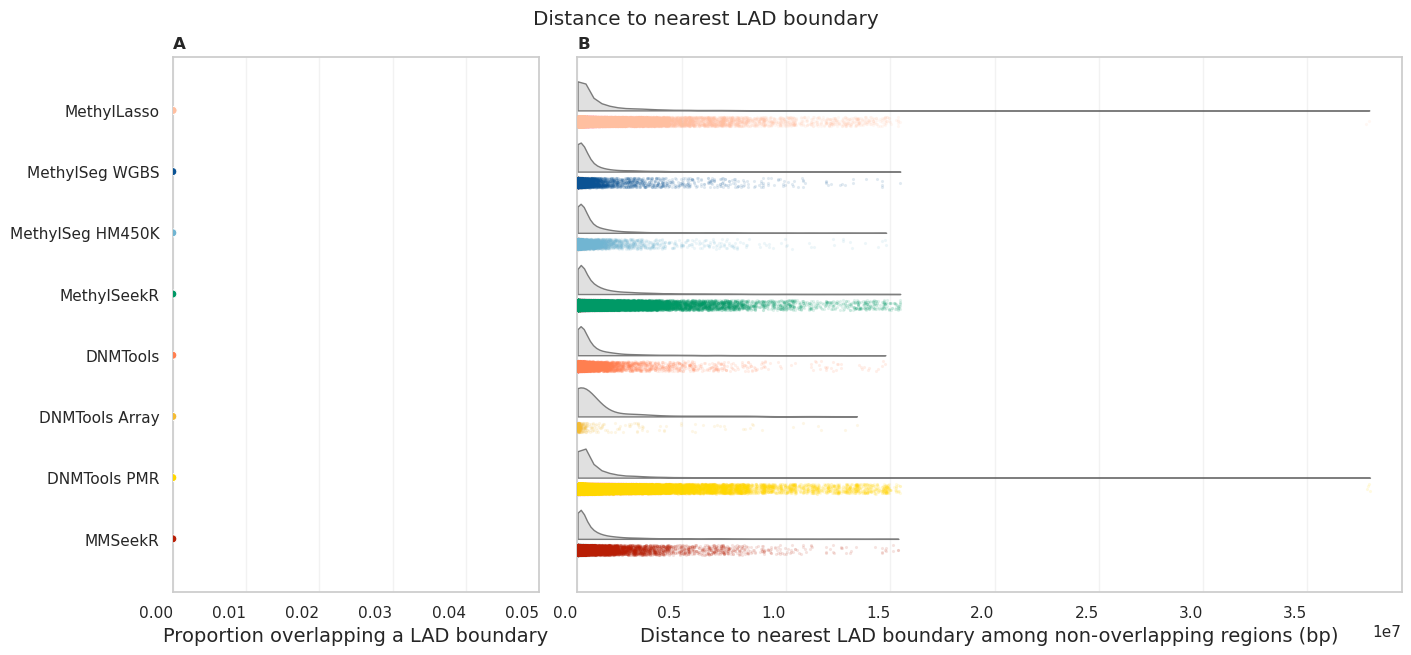

Saved LAD violin figures to /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/05_lad/violin_metrics/all_samples
Saved LAD coverage scatter figures to /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/05_lad/coverage_scatter/all_samples
Saved LAD distance summary figures to /uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/figures/out/05_lad/distance_summary_metrics/all_samples


In [45]:
distance_summary_output_dir = OUTPUT_DIR / "distance_summary_metrics" / plot_sample_label
distance_summary_metric_specs = [
    {
        "metric_name": "dist_to_lad",
        "base_title": "Distance to nearest LAD",
        "xlabel": "Distance to nearest LAD (bp, log scale)",
        "use_two_panel": True,
        "overlap_xlabel": "Proportion overlapping a LAD",
        "distance_xlabel": "Distance to nearest LAD among non-overlapping regions (bp)",
    },
    {
        "metric_name": "dist_to_lad_boundary",
        "base_title": "Distance to nearest LAD boundary",
        "xlabel": "Distance to nearest LAD boundary (bp, log scale)",
        "use_two_panel": True,
        "overlap_xlabel": "Proportion overlapping a LAD boundary",
        "distance_xlabel": "Distance to nearest LAD boundary among non-overlapping regions (bp)",
    },
]

for metric_spec in distance_summary_metric_specs:
    metric_name = metric_spec["metric_name"]
    base_title = metric_spec["base_title"]
    xlabel = metric_spec["xlabel"]
    distance_summary_df = filter_lad_region_plot_df(
        lad_boundary_distance_details_df,
        REGION_PLOT_SAMPLE_ID,
    )
    if distance_summary_df.empty:
        raise RuntimeError(
            f"No distance-summary rows available for {metric_name!r} with REGION_PLOT_SAMPLE_ID={REGION_PLOT_SAMPLE_ID!r}"
        )
    figure_title = (
        base_title if REGION_PLOT_SAMPLE_ID is None else f"{base_title} ({plot_title_label})"
    )
    if metric_spec.get("use_two_panel", False):
        fig, _ = plot_lad_distance_two_panel(
            distance_summary_df,
            value_col=metric_name,
            title=figure_title,
            overlap_xlabel=metric_spec["overlap_xlabel"],
            distance_xlabel=metric_spec["distance_xlabel"],
        )
    else:
        fig, _ = plot_lad_metric_dotwhisker(
            distance_summary_df,
            value_col=metric_name,
            title=figure_title,
            xlabel=xlabel,
        )
    save_publication_figure(
        fig,
        distance_summary_output_dir,
        f"distance_summary.{metric_name}.png",
        save_pdf=SAVE_PDF,
    )
    plt.show()
    plt.close(fig)

print(f"Saved LAD violin figures to {violin_output_dir}")
print(f"Saved LAD coverage scatter figures to {coverage_scatter_output_dir}")
print(f"Saved LAD distance summary figures to {distance_summary_output_dir}")
